In [1]:
import os
import numpy as np
import pymc as pm
import pytensor
from pathlib import Path
from tqdm.notebook import tqdm

if os.environ.get("SIMPLEVI_PYTENSOR_CXX"):
    pytensor.config.cxx = os.environ["SIMPLEVI_PYTENSOR_CXX"]

from modulars.distributions import gen_multinomial_data_shared, lda_posterior_shared_theta
from modulars.utils import (
    load_config, load_best_multid_reference, save_to_csv,
    load_from_csv, find_best_params, anchored_softmax_simplex_forward,
    stickbreaking_simplex_forward, apply_traj_transform_simplex_from_cov,
    build_summary_runs_from_cov_results, simplex_moments_from_cov,
    anchored_simplex_inverse, stickbreaking_simplex_inverse,
    offdiag_ratio, latent_diag_diagnostic
)
from modulars.plot_rr import (
    plot_simplex_dims, plot_dirichlet_marginals_few_restarts,
    plot_dirichlet_mean_band_rrs, plot_dirichlet_simplex_pdf_zoom,
)
from modulars.pymc_rr_test import run_pymc_VI, StickBreakingSimplexTransform
from pymc.model.transform.conditioning import change_value_transforms

In [2]:
config_file = "dirichlet_config.json"
config = load_config(config_file)
results_dir = Path("results")

theta_like = np.array(config["theta_like"], dtype=np.float32)
alpha_prior = np.array(config["alpha_prior"], dtype=np.float32)
n_cats = config["n_cats"]
N = config["N"]
total_count = config["total_count"]
max_iters = 50_000
n_restarts = 10
seed = config.get("seed", 15)

n_vec = np.full(N, total_count, dtype=int)

obs_counts = gen_multinomial_data_shared(theta_like, N, total_count, SEED=seed)
true_post = lda_posterior_shared_theta(observations=obs_counts, alpha=alpha_prior)

best_mean, best_cov, best_std = load_best_multid_reference(config)

scenario_meta = {
    "default": {
        "title": "PyMC Default",
        "forward_fn": anchored_softmax_simplex_forward,
        "n_mc_samps": 1,
    },
    "mc100_only": {
        "title": "PyMC 100 MC Only",
        "forward_fn": anchored_softmax_simplex_forward,
        "n_mc_samps": 100,
    },
    "adam_only": {
        "title": "PyMC Adam Only",
        "forward_fn": anchored_softmax_simplex_forward,
        "n_mc_samps": 1,
    },
    "mc100_adam": {
        "title": "PyMC 100 MC + Adam",
        "forward_fn": anchored_softmax_simplex_forward,
        "n_mc_samps": 100,
    },
    "stickbreaking_only": {
        "title": "PyMC Stick-Breaking Only",
        "forward_fn": stickbreaking_simplex_forward,
        "n_mc_samps": 1,
    },
    "stickbreaking_mc100": {
        "title": "PyMC Stick-Breaking + 100 MC",
        "forward_fn": stickbreaking_simplex_forward,
        "n_mc_samps": 100,
    },
    "stickbreaking_adam": {
        "title": "PyMC Stick-Breaking + Adam",
        "forward_fn": stickbreaking_simplex_forward,
        "n_mc_samps": 1,
    },
    "stickbreaking_mc100_adam": {
        "title": "PyMC Stick-Breaking + 100 MC + Adam",
        "forward_fn": stickbreaking_simplex_forward,
        "n_mc_samps": 100,
    }

}

In [3]:
def build_pymc_dirichlet_model(
        alpha_prior,
        n_vec,
        obs_counts,
        n_cats,
        simplex_transform="default"):
    """
    we build the standard PyMC Dirichlet-multinomial model.

    For the stick-breaking case, we replace PyMC's default simplex transform
    with the custom stick-breaking transform.
    """
    with pm.Model() as model:
        if simplex_transform == "default":
            theta = pm.Dirichlet("theta", a=alpha_prior)
        elif simplex_transform == "stickbreaking":
            theta = pm.Dirichlet(
                "theta",
                a=alpha_prior,
                default_transform=StickBreakingSimplexTransform(),
            )
        else:
            raise ValueError(
                "we expected simplex_transform to be 'default' or 'stickbreaking'"
            )

        pm.Multinomial("y", n=n_vec, p=theta, observed=np.array(obs_counts))

    return model


def run_model(n_mc_samples=1, optimizer="default", seed=1, simplex_transform='default'):
    
    with build_pymc_dirichlet_model(
        alpha_prior,
        n_vec,
        obs_counts,
        n_cats,
        simplex_transform=simplex_transform,
    ) as model:
        tracked_vals = run_pymc_VI(
            model,
            n_mc_samples=n_mc_samples,
            n_iters=max_iters,
            optimizer=optimizer,
            seed=seed,
            SINGLE_DIM=False,
        )

    return tracked_vals

def run_single_seed_pymc_scenarios(
        seed,
        alpha_prior,
        n_vec,
        obs_counts,
        n_cats,
        n_iters,
        scenario_name):
    """
    we run the five PyMC scenarios we want to compare under one common interface.

    The first four scenarios use the default PyMC simplex transform.
    The last scenarios uses the same PyMC model and same PyMC ADVI, but swaps
    only theta's value transform to stick-breaking coordinates.
    """
    scenario_kwargs = {
        "default": {
            "n_mc_samples": 1,
            "optimizer": "default",
            "simplex_transform": "default",
        },
        "mc100_only": {
            "n_mc_samples": 100,
            "optimizer": "default",
            "simplex_transform": "default",
        },
        "adam_only": {
            "n_mc_samples": 1,
            "optimizer": "adam",
            "simplex_transform": "default",
        },
        "mc100_adam": {
            "n_mc_samples": 100,
            "optimizer": "adam",
            "simplex_transform": "default",
        },
        "stickbreaking_only": {
            "n_mc_samples": 1,
            "optimizer": "default",
            "simplex_transform": "stickbreaking",
        },
        "stickbreaking_mc100": {
            "n_mc_samples": 100,
            "optimizer": "default",
            "simplex_transform": "stickbreaking",
        },
        "stickbreaking_adam": {
            "n_mc_samples": 1,
            "optimizer": "adam",
            "simplex_transform": "stickbreaking",
        },
        "stickbreaking_mc100_adam": {
            "n_mc_samples": 100,
            "optimizer": "adam",
            "simplex_transform": "stickbreaking",
        }
    }

    dirichlet_kwargs = {
        'alpha_prior': alpha_prior,
        'n_vec': n_vec,
        'obs_counts': obs_counts,
        'n_cats': n_cats,
    }

    pymc_VI_kwargs = {
        "n_iters": n_iters,
        "seed": seed,
        "SINGLE_DIM": False,
    }

    def build_model(which_scenario):
        return build_pymc_dirichlet_model(
            simplex_transform=scenario_kwargs[which_scenario]['simplex_transform'],
            **dirichlet_kwargs
        )
    def run_pymc_VI_scenario(which_scenario):
        model = build_model(which_scenario)
        return run_pymc_VI(
            model, **pymc_VI_kwargs,
            **scenario_kwargs[which_scenario]
        )

    if scenario_name == 'all':
        scenarios = {}
        for name in scenario_kwargs.keys():
            print(f"Running scenario: {name}")
            scenarios[name] = run_pymc_VI_scenario(name)
        return scenarios
    else:
        assert scenario_name in scenario_kwargs, f"scenario_name must be one of {list(scenario_kwargs.keys())} or 'all'"
        print(f"Running scenario: {scenario_name}")
        return {scenario_name: run_pymc_VI_scenario(scenario_name)}
   

In [4]:
for scenario in scenario_meta.keys():
    individual_scenario_results = {scenario: []}

    for rr_seed in tqdm(range(n_restarts)):
        results = run_single_seed_pymc_scenarios(
            seed=rr_seed,
            alpha_prior=alpha_prior,
            n_vec=n_vec,
            obs_counts=obs_counts,
            n_cats=n_cats,
            n_iters=max_iters,
            scenario_name=scenario,
        )

        for scenario_name, tracked_vals in results.items():
            individual_scenario_results[scenario_name].append(tracked_vals)
        
    save_to_csv(results_dir / f"pymc_scenario_raw_results_{scenario}.csv", [individual_scenario_results])

  0%|          | 0/10 [00:00<?, ?it/s]

Running scenario: default


Finished [100%]: Average Loss = 54.964


Running scenario: default


Finished [100%]: Average Loss = 55.014


...

Finished [100%]: Average Loss = 54.833


Running scenario: stickbreaking_mc100_adam


Finished [100%]: Average Loss = 54.833


Running scenario: stickbreaking_mc100_adam


Finished [100%]: Average Loss = 54.833


In [5]:
# since we're processing them scenario by 
# scenario anyway, we don't bother with a single
# all-scenario results file, so load them all back in
loaded_scenario_dict = {
    scenario: load_from_csv(results_dir / f"pymc_scenario_raw_results_{scenario}.csv")[0][scenario]
    for scenario in scenario_meta.keys()
}

In [6]:
def process_single_pymc_scenario_results(
        raw_results,
        n_cats,
        forward_fn,
        n_samples=50_000,
        seed=10):
    """
    we process one scenario where each restart stores only one latent mean/cov trajectory.
    """
    means = []
    stds = []

    for loc_traj, cov_traj in tqdm(raw_results):
        mean_traj, std_traj = simplex_moments_from_cov(
            loc_traj,
            cov_traj,
            n_cats=n_cats,
            forward_fn=forward_fn,
            n_samples=n_samples,
            seed=seed,
        )
        means.append(mean_traj)
        stds.append(std_traj)

    return np.asarray(means), np.asarray(stds)


In [7]:
def build_summary_runs_from_single_cov_results(
        raw_results,
        n_cats,
        forward_fn,
        n_samples=50_000,
        seed=0):
    """
    we build final simplex summaries for one scenario where each restart stores
    only one latent mean/cov trajectory.
    """
    summary_runs = []

    for restart_idx, (loc_traj, cov_traj) in enumerate(raw_results):
        final_loc = np.asarray(loc_traj[-1], dtype=float)
        final_cov = np.asarray(cov_traj[-1], dtype=float)

        rng = np.random.default_rng(seed + restart_idx)
        z = rng.multivariate_normal(
            mean=final_loc,
            cov=final_cov,
            size=int(n_samples),
        )
        theta = forward_fn(z, n_cats=n_cats)

        summary_runs.append(
            {
                "restart_idx": restart_idx,
                "mean": theta.mean(axis=0),
                "cov": np.cov(theta, rowvar=False),
            }
        )

    return summary_runs


In [8]:
processed_scenarios = {}
summary_files = {}

for scenario_name, raw_results in tqdm(loaded_scenario_dict.items()):
    meta = scenario_meta[scenario_name]
    forward_fn = meta["forward_fn"]

    means, stds = process_single_pymc_scenario_results(
        raw_results,
        n_cats=n_cats,
        forward_fn=forward_fn,
        n_samples=20_000,
        seed=10,
    )

    processed_scenarios[scenario_name] = (means, stds)

    save_to_csv(
        results_dir / f"pymc_processed_{scenario_name}.csv",
        [(means, stds)],
    )

    summary_runs = build_summary_runs_from_single_cov_results(
        raw_results,
        n_cats=n_cats,
        forward_fn=forward_fn,
        n_samples=20_000,
        seed=seed,
    )

    summary_file = results_dir / f"pymc_summary_{scenario_name}.csv"
    save_to_csv(summary_file, summary_runs)
    summary_files[scenario_name] = summary_file


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [7]:
def plot_pymc_scenario(processed, summary_file, title_prefix, n_mc_samps):
    means, stds = processed

    local_best = find_best_params(
        [summary_file],
        alpha_prior=alpha_prior,
        obs_counts=obs_counts,
        grad_samps=100,
        seed=seed,
    )

    plot_dirichlet_marginals_few_restarts(
        means,
        stds,
        true_alpha_post=true_post["alpha_post"],
        true_mu_post=true_post["mean_post"],
        true_sigma_post=true_post["std_post"],
        best_mean=best_mean,
        best_cov=best_cov,
        which_restarts=list(range(min(3, n_restarts))),
        iteration=-1,
        label_prefix=title_prefix + " ",
    )

    plot_dirichlet_mean_band_rrs(
        means,
        stds,
        best_mean=best_mean,
        best_cov=best_cov,
        param_name=r"$\theta$",
        which_dims=list(range(n_cats)),
        n_mc_samps=n_mc_samps,
        label_prefix=title_prefix + " ",
    )

    if n_cats == 3:
        plot_dirichlet_simplex_pdf_zoom(
            true_alpha_post=true_post["alpha_post"],
            best_mean=best_mean,
            best_cov=best_cov,
            overlay_mean=local_best["best_mean"],
            overlay_cov=local_best["best_cov"],
            title_prefix="",
            zoom_quantile=0.98,
            zoom_padding=0.04,
            framework_name=title_prefix
        )


# loaded after here

In [4]:
loaded_processed_scenarios = {}
loaded_summary_files = {}

for scenario_name in scenario_meta:
    loaded_processed_scenarios[scenario_name] = load_from_csv(
        results_dir / f"pymc_processed_{scenario_name}.csv"
    )[0]

    loaded_summary_files[scenario_name] = (
        results_dir / f"pymc_summary_{scenario_name}.csv"
    )


In [5]:
for scenario_name, meta in scenario_meta.items():
    local_best = find_best_params(
        [loaded_summary_files[scenario_name]],
        alpha_prior=alpha_prior,
        obs_counts=obs_counts,
        grad_samps=100,
        seed=seed,
    )

    print(meta["title"])
    print("  best elbo:", local_best["best_elbo_np"])
    print("  best mean:", local_best["best_mean"])
    print("  mean diff from config:", local_best["best_mean"] - best_mean)
    print("  best std:", np.sqrt(np.clip(np.diag(local_best["best_cov"]), 0.0, None)))
    print("  std diff from config:", np.sqrt(np.clip(np.diag(local_best["best_cov"]), 0.0, None)) - best_std)
    print("  cov frobenius diff from config:", np.linalg.norm(local_best["best_cov"] - best_cov, ord="fro"))
    print()


18.2971
18.240837
18.231733
18.249743
18.265472
18.2554
18.289045
18.252218
18.278088
18.317522
PyMC Default
  best elbo: -18.231733322143555
  best mean: [0.40547679 0.2929962  0.301527  ]
  mean diff from config: [ 0.00023593 -0.00108872  0.00085279]
  best std: [0.02139002 0.01896386 0.02729128]
  std diff from config: [-0.00064745 -0.00146552  0.00675944]
  cov frobenius diff from config: 0.0005455962609958049

18.44442
18.439621
18.44405
18.43403
18.46127
18.44572
18.45862
18.448195
18.479328
18.440245
PyMC 100 MC Only
  best elbo: -18.434030532836914
  best mean: [0.40504869 0.29432216 0.30062915]
  mean diff from config: [-1.92167418e-04  2.37238499e-04 -4.50708908e-05]
  best std: [0.01951437 0.01728457 0.0249185 ]
  std diff from config: [-0.0025231  -0.00314481  0.00438666]
  cov frobenius diff from config: 0.0004406085978774554

18.468195
18.426287
18.396563
18.446198
18.451817
18.344015
18.469696
18.426569
18.411806
18.57768
PyMC Adam Only
  best elbo: -18.34401512145996
  

18.2971
18.240837
18.231733
18.249743
18.265472
18.2554
18.289045
18.252218
18.278088
18.317522


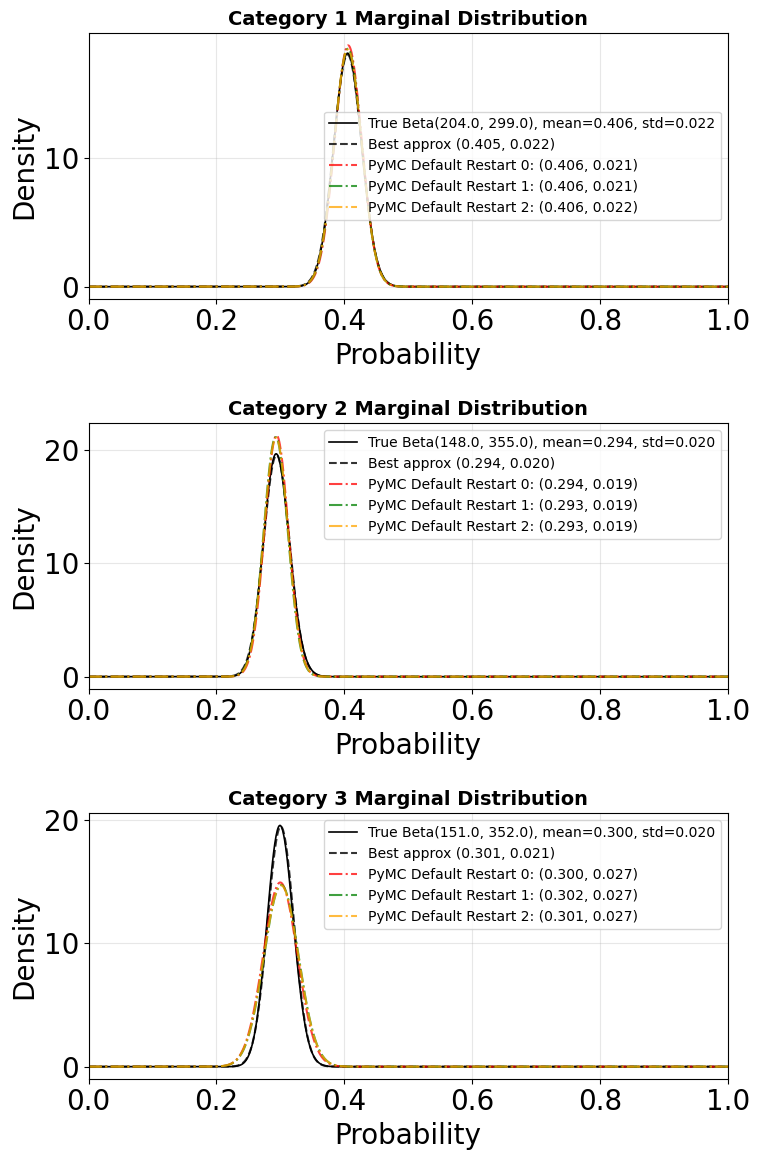

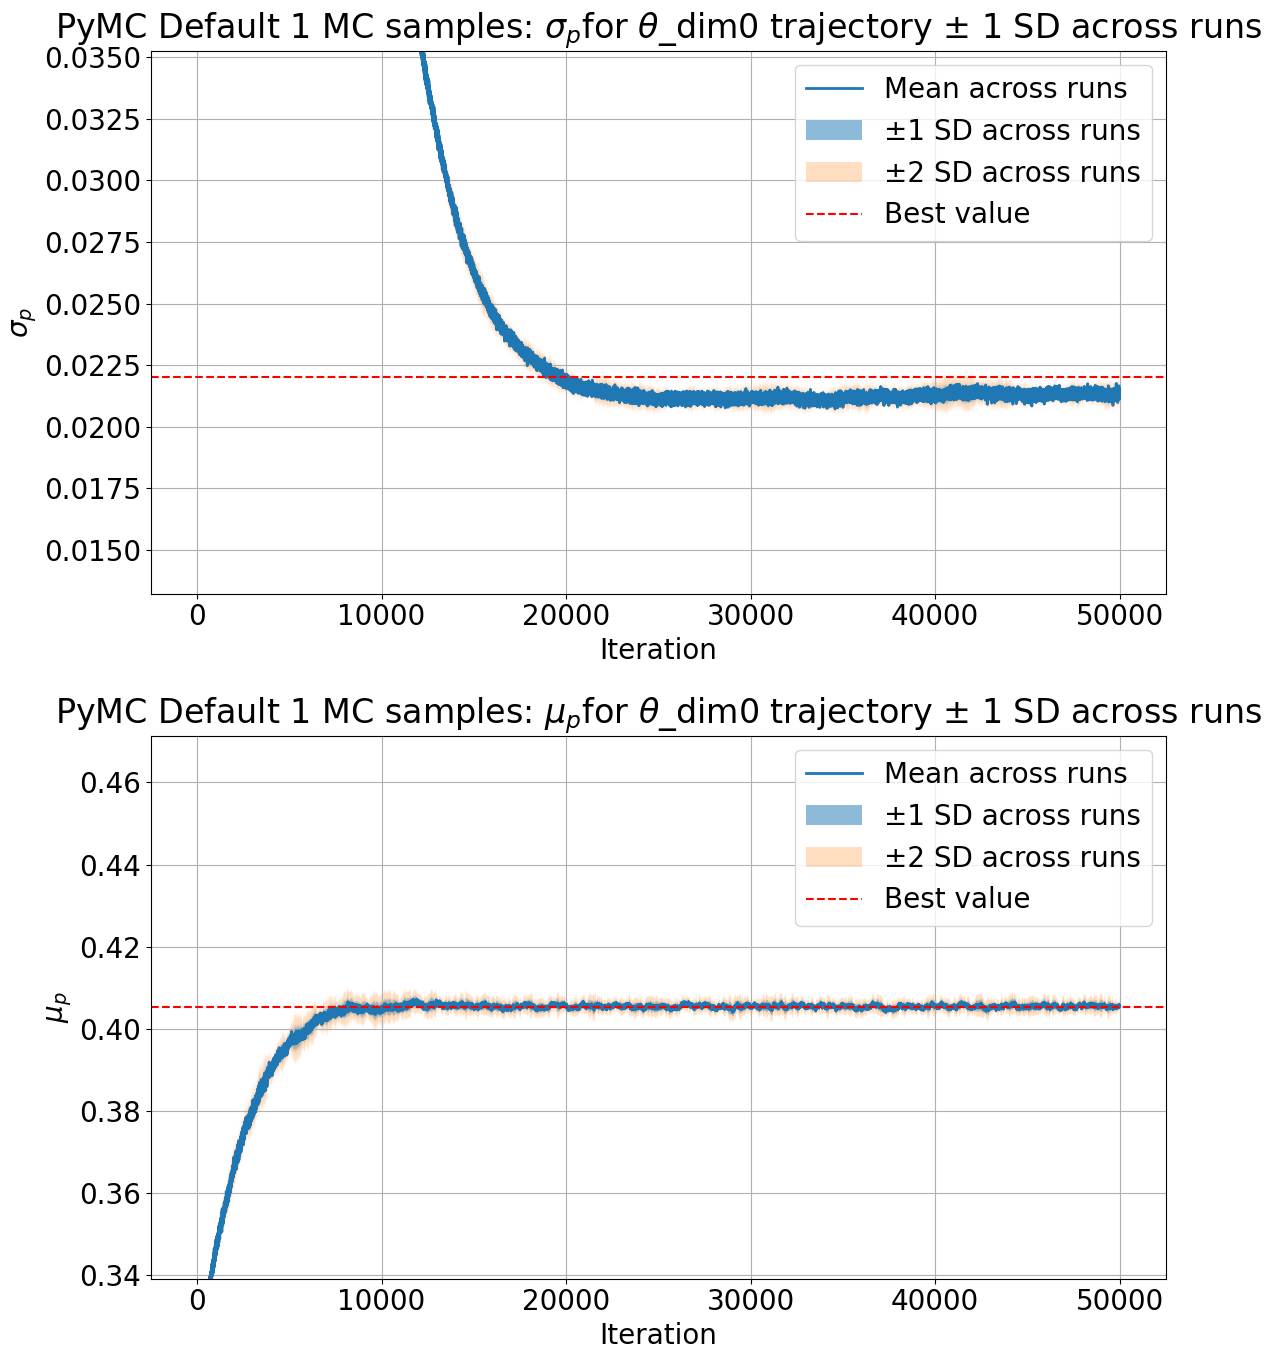

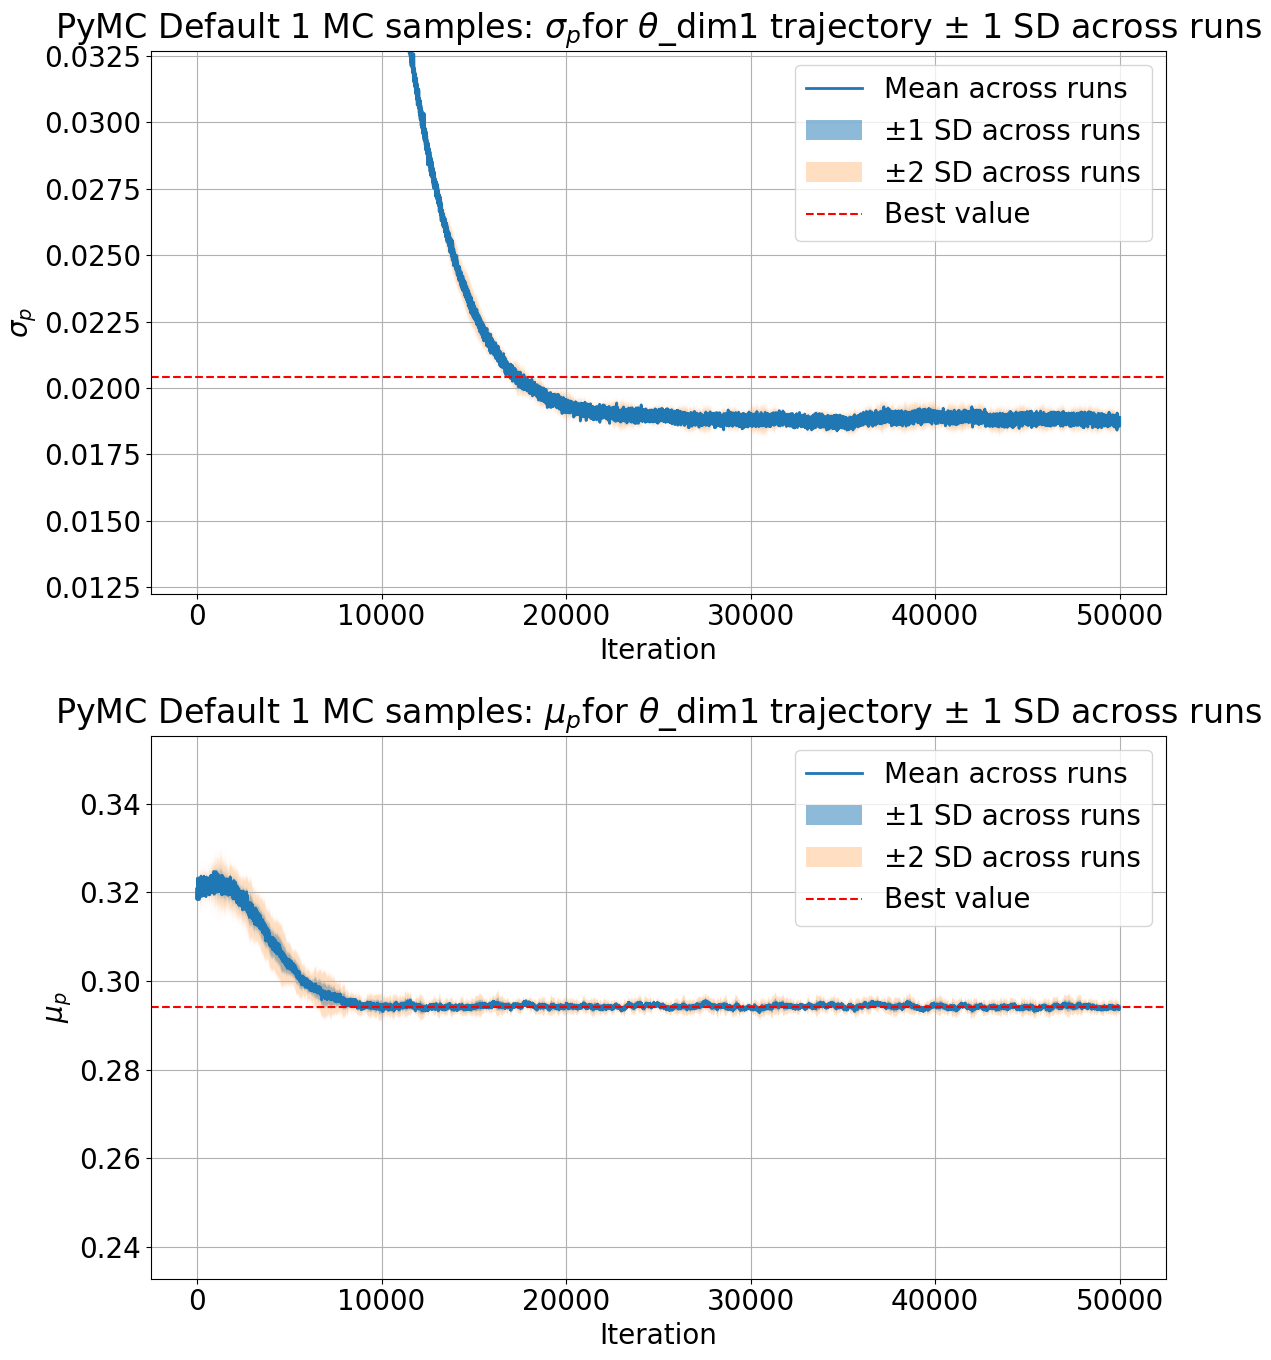

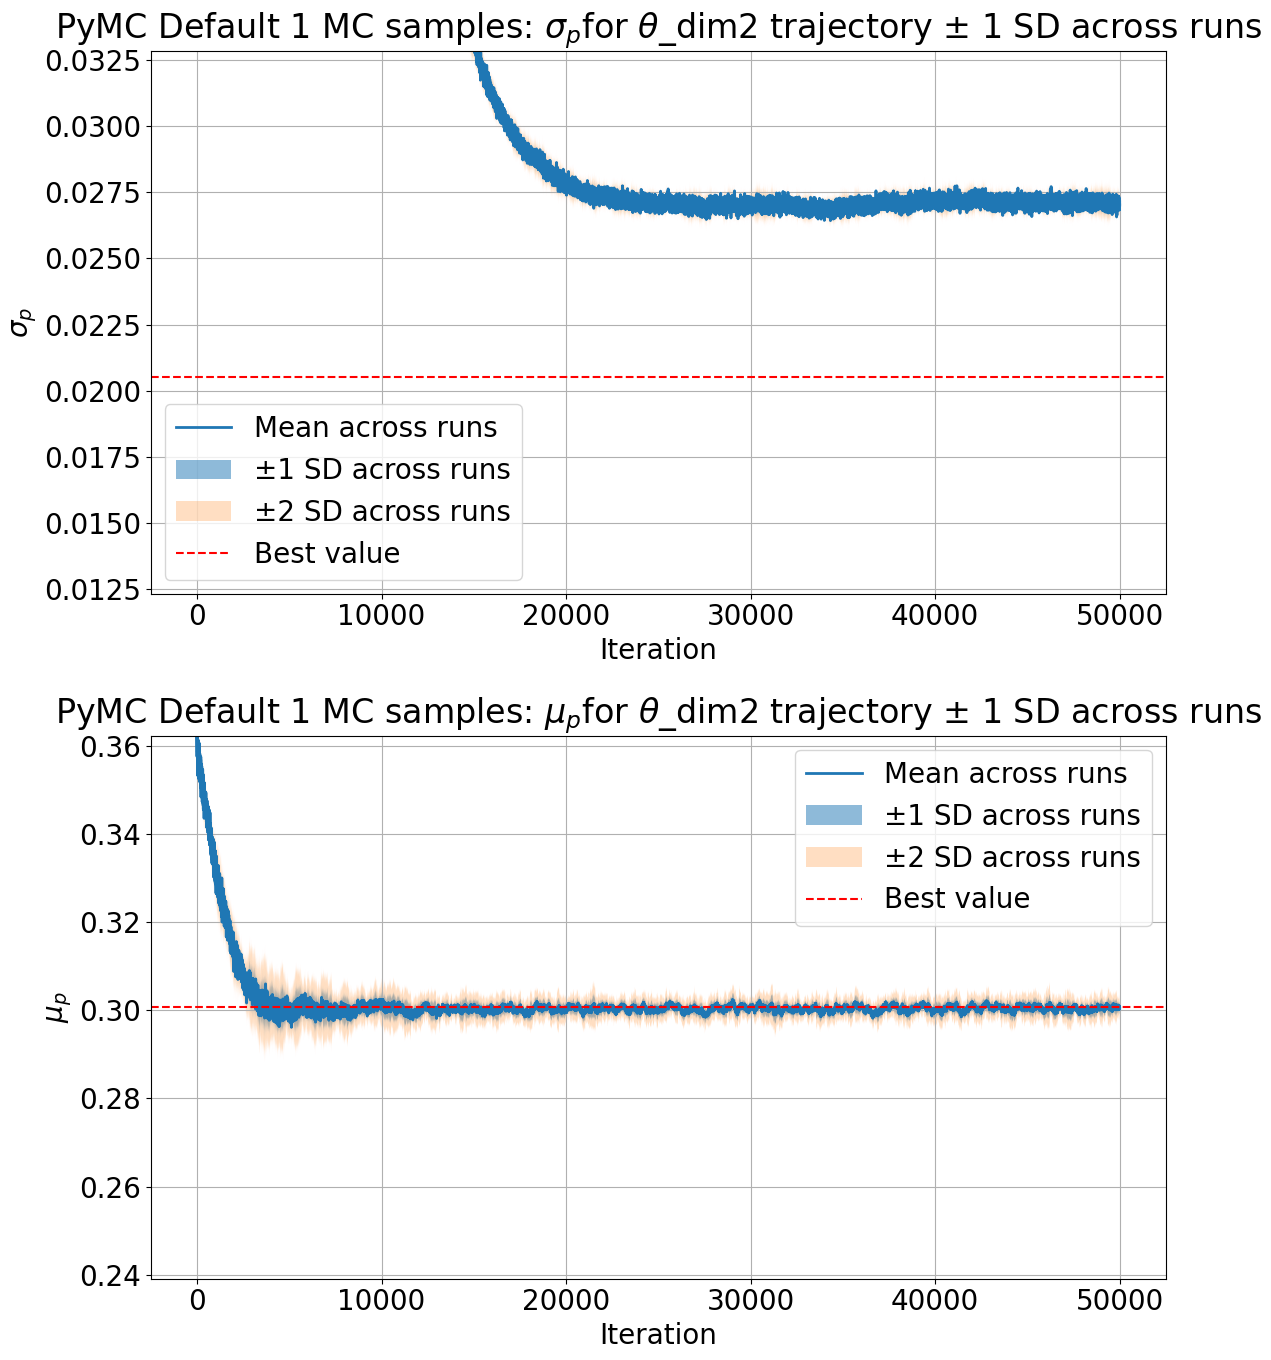

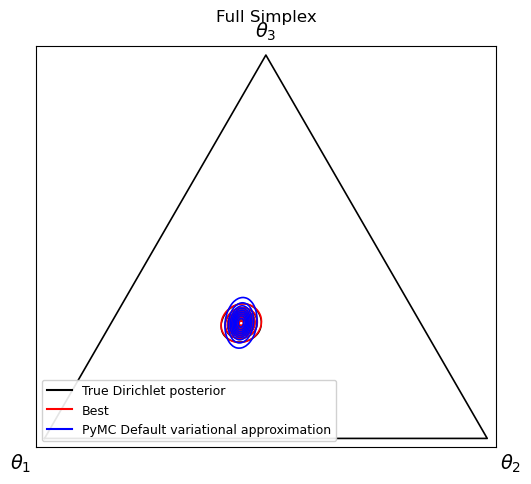

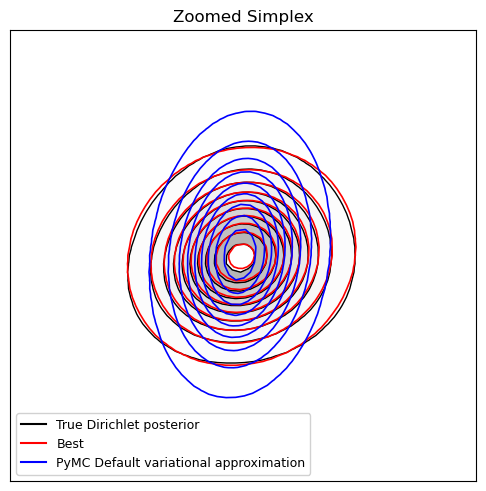

18.44442
18.439621
18.44405
18.43403
18.46127
18.44572
18.45862
18.448195
18.479328
18.440245


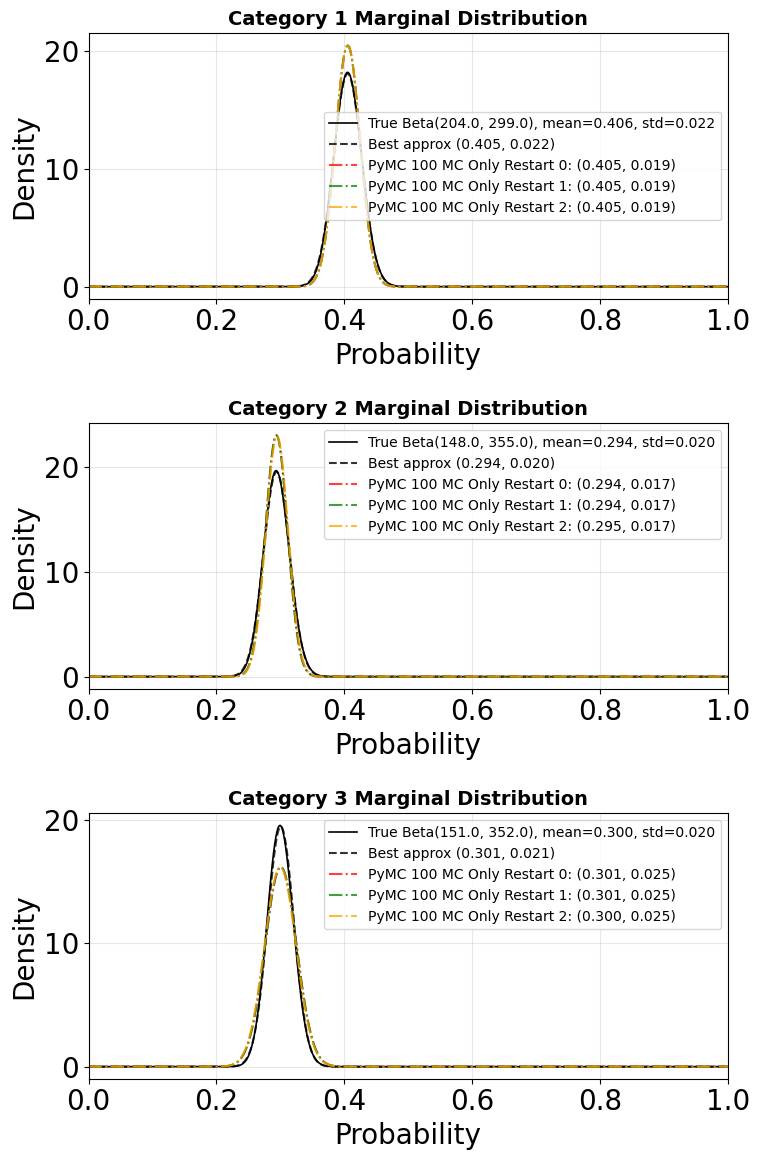

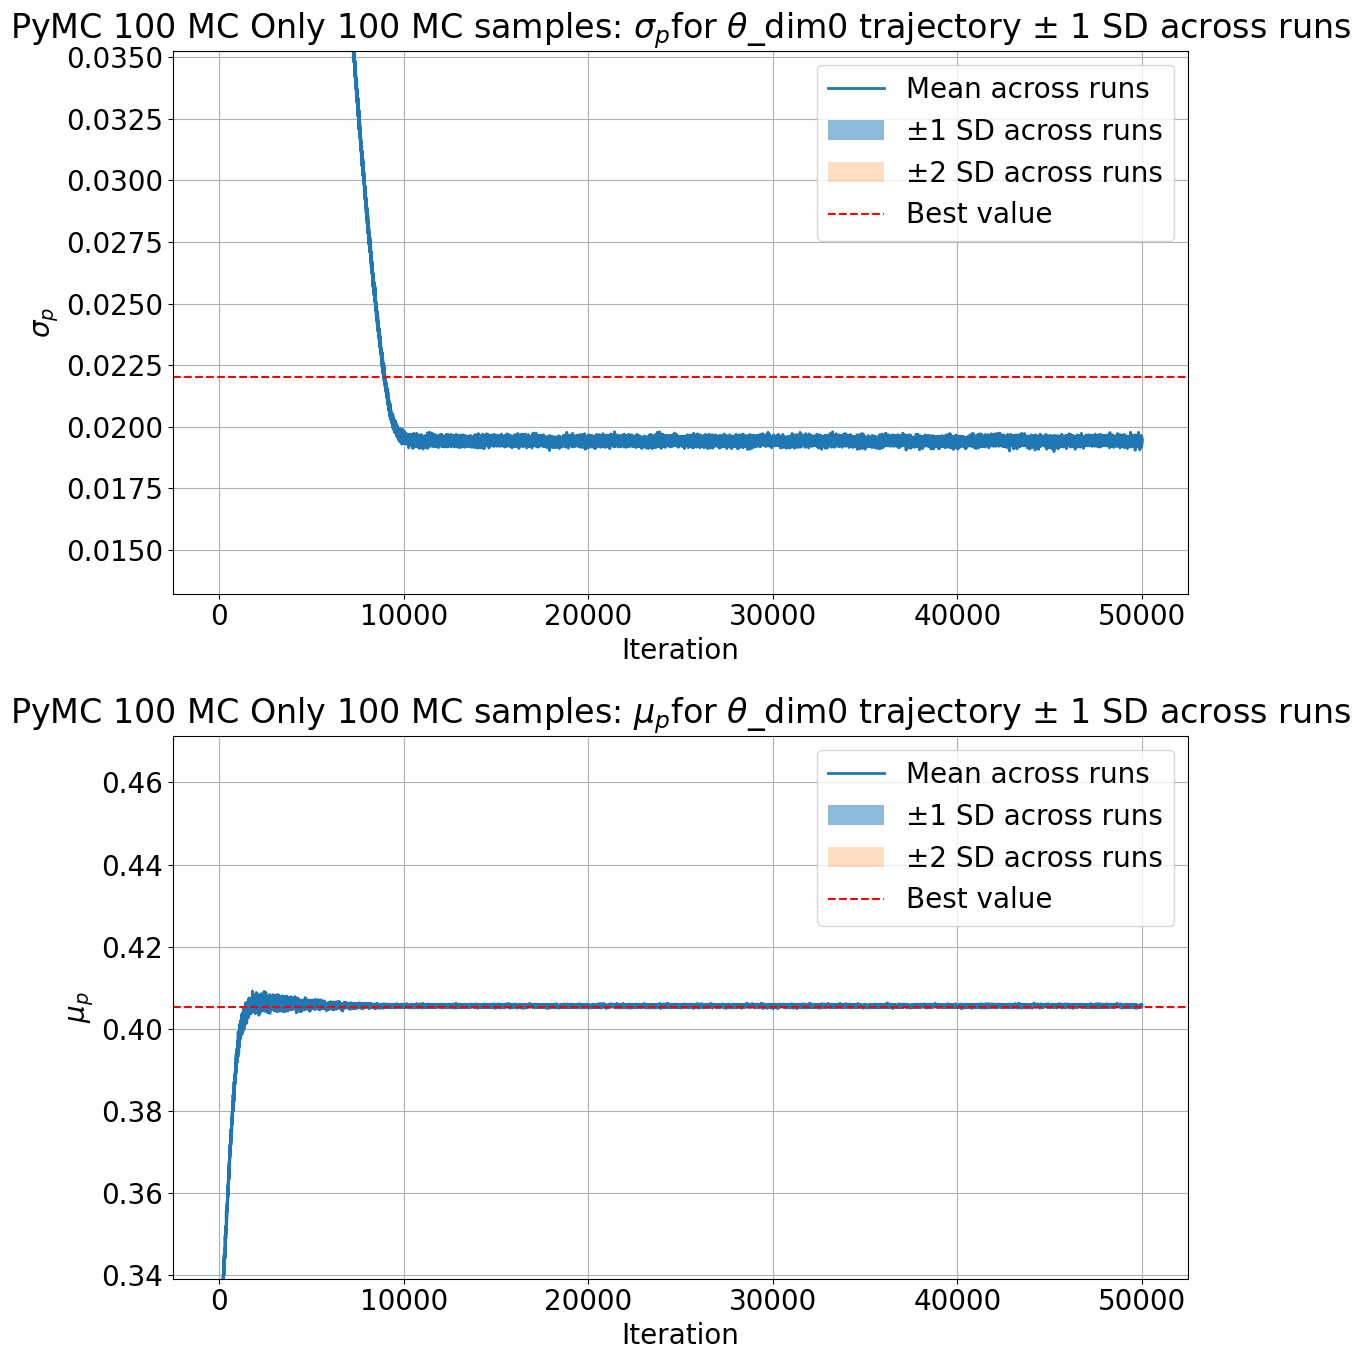

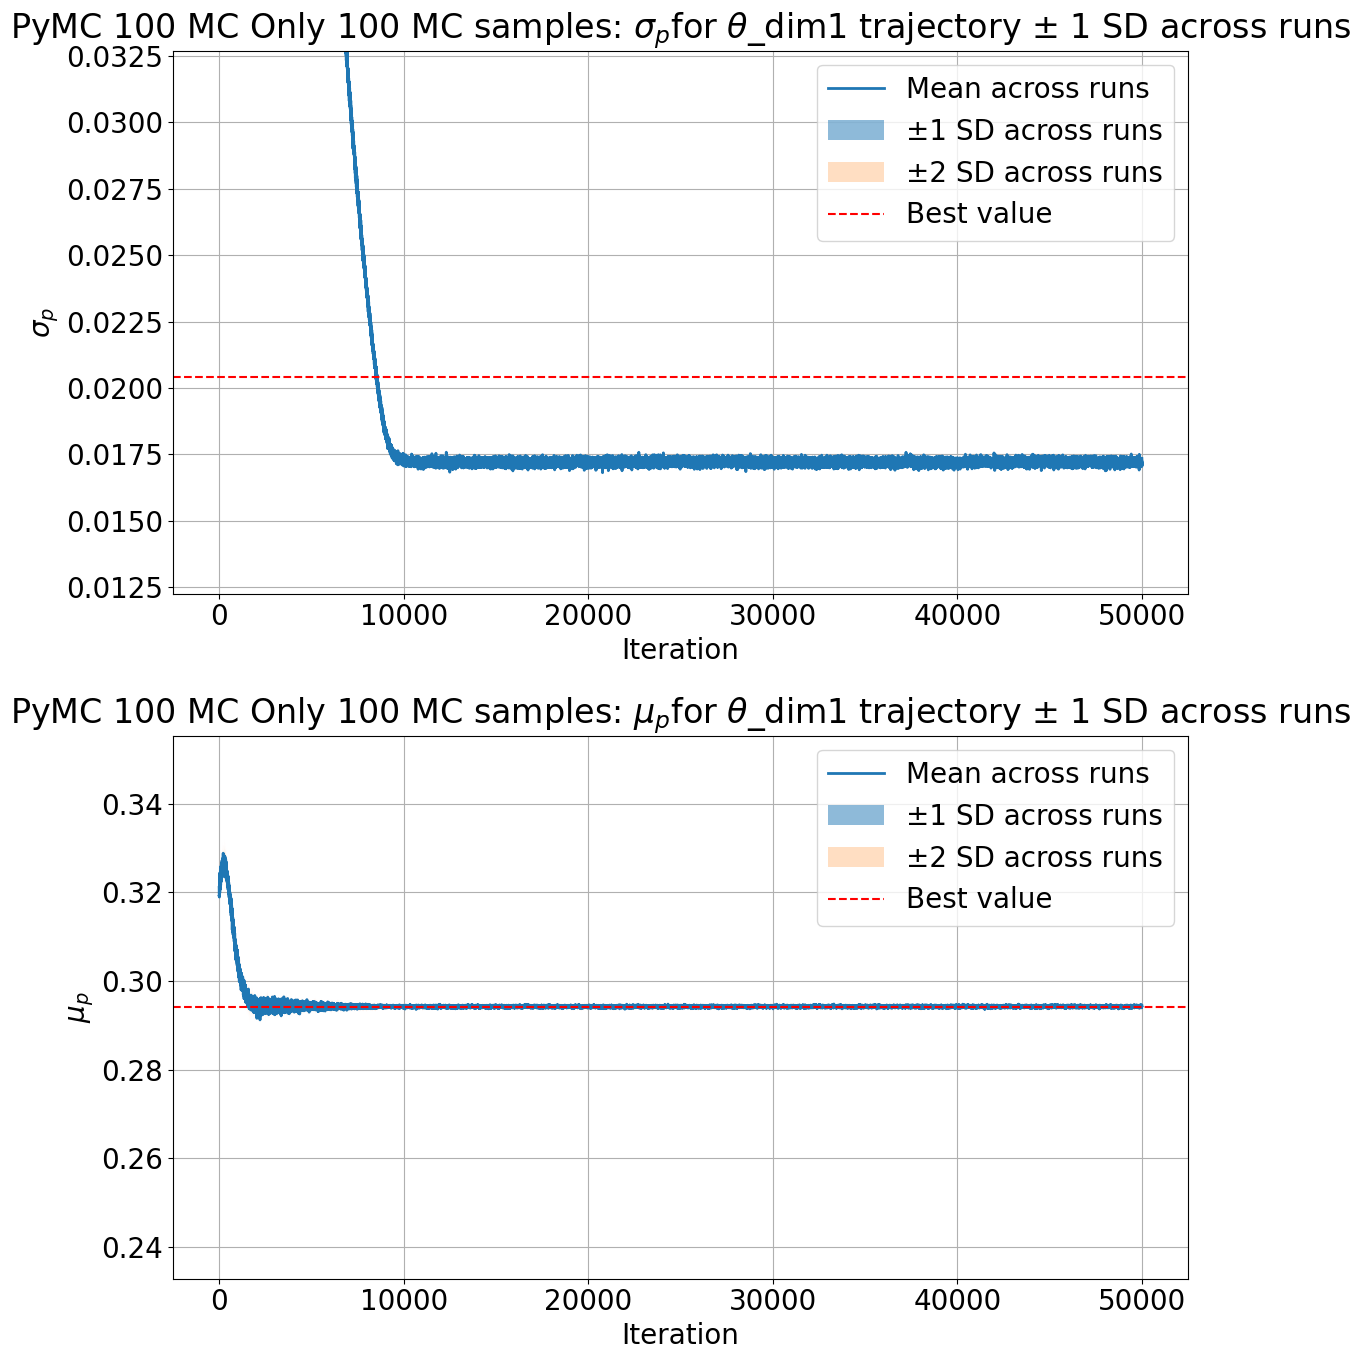

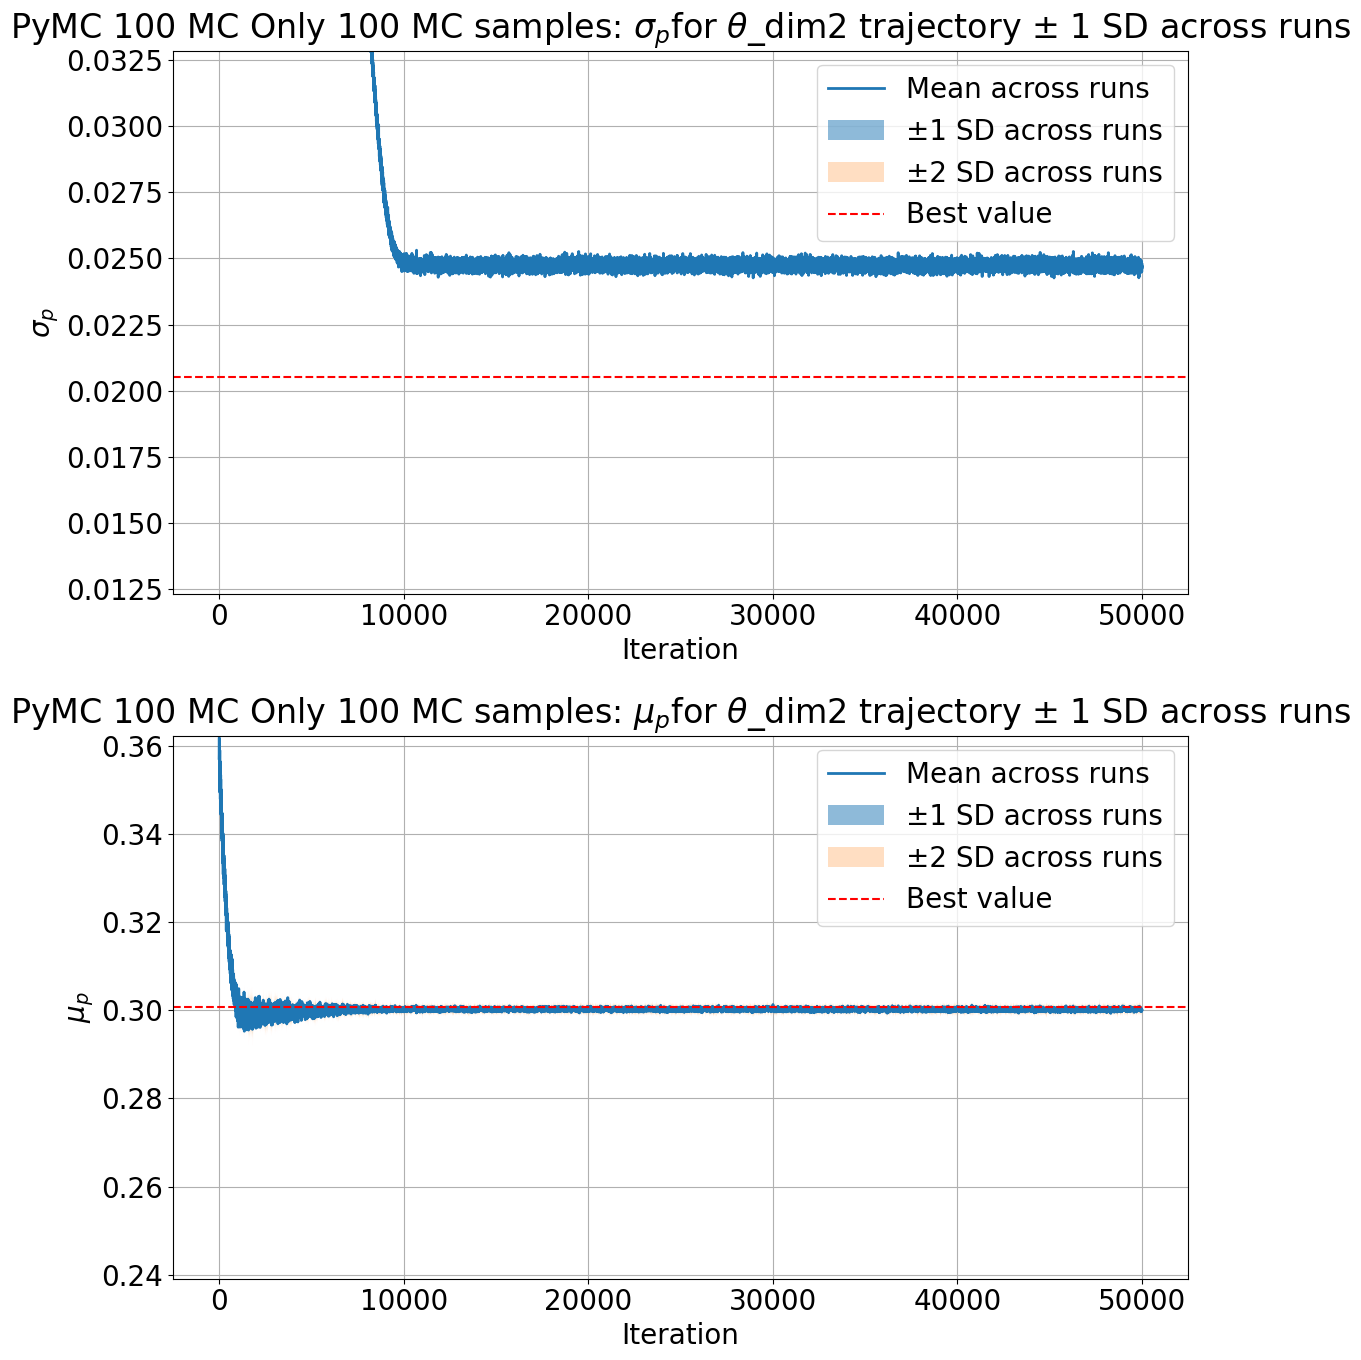

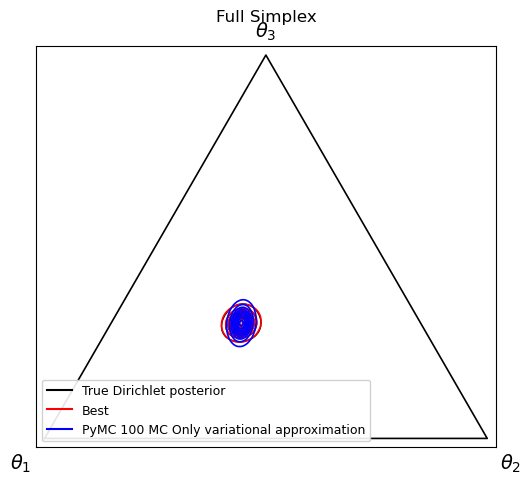

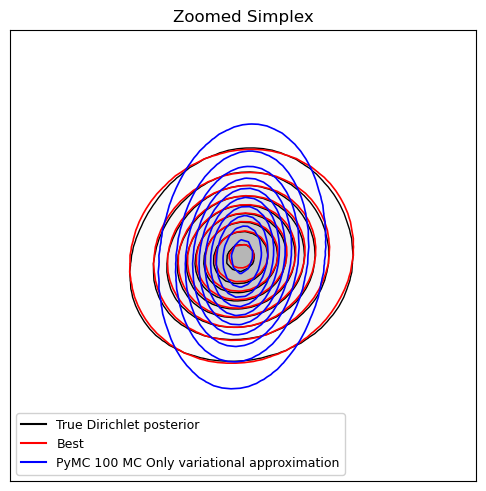

18.468195
18.426287
18.396563
18.446198
18.451817
18.344015
18.469696
18.426569
18.411806
18.57768


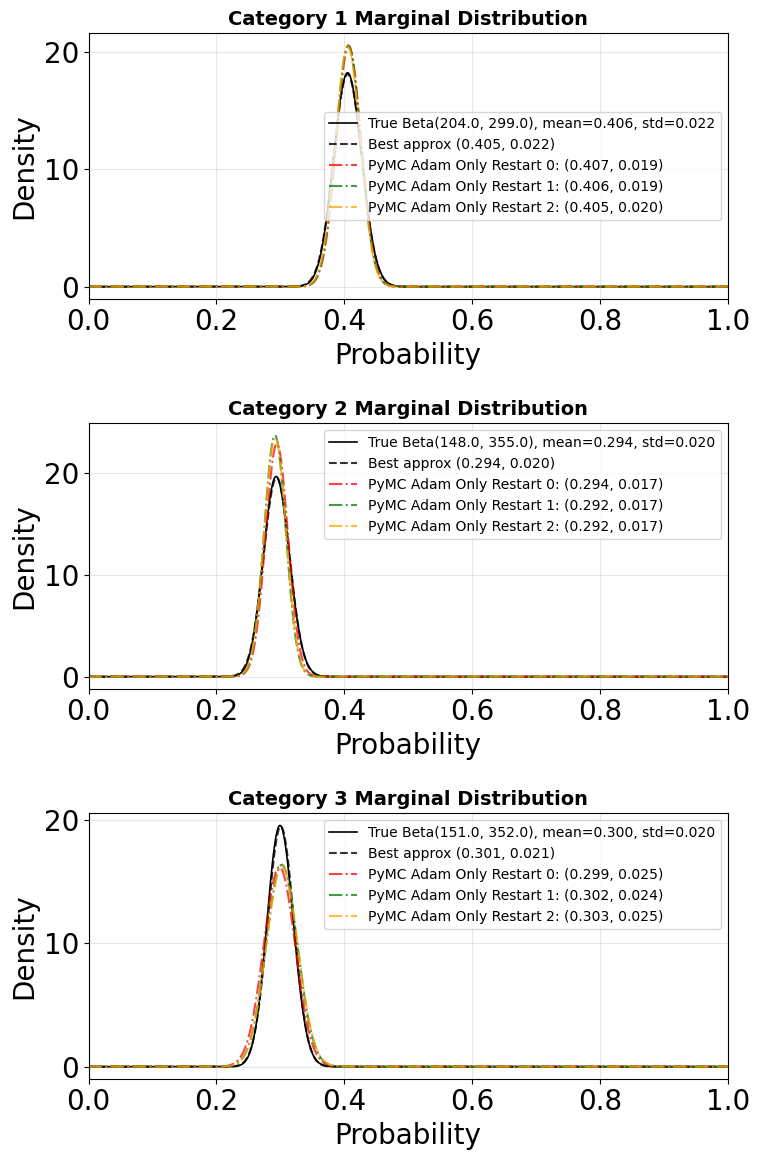

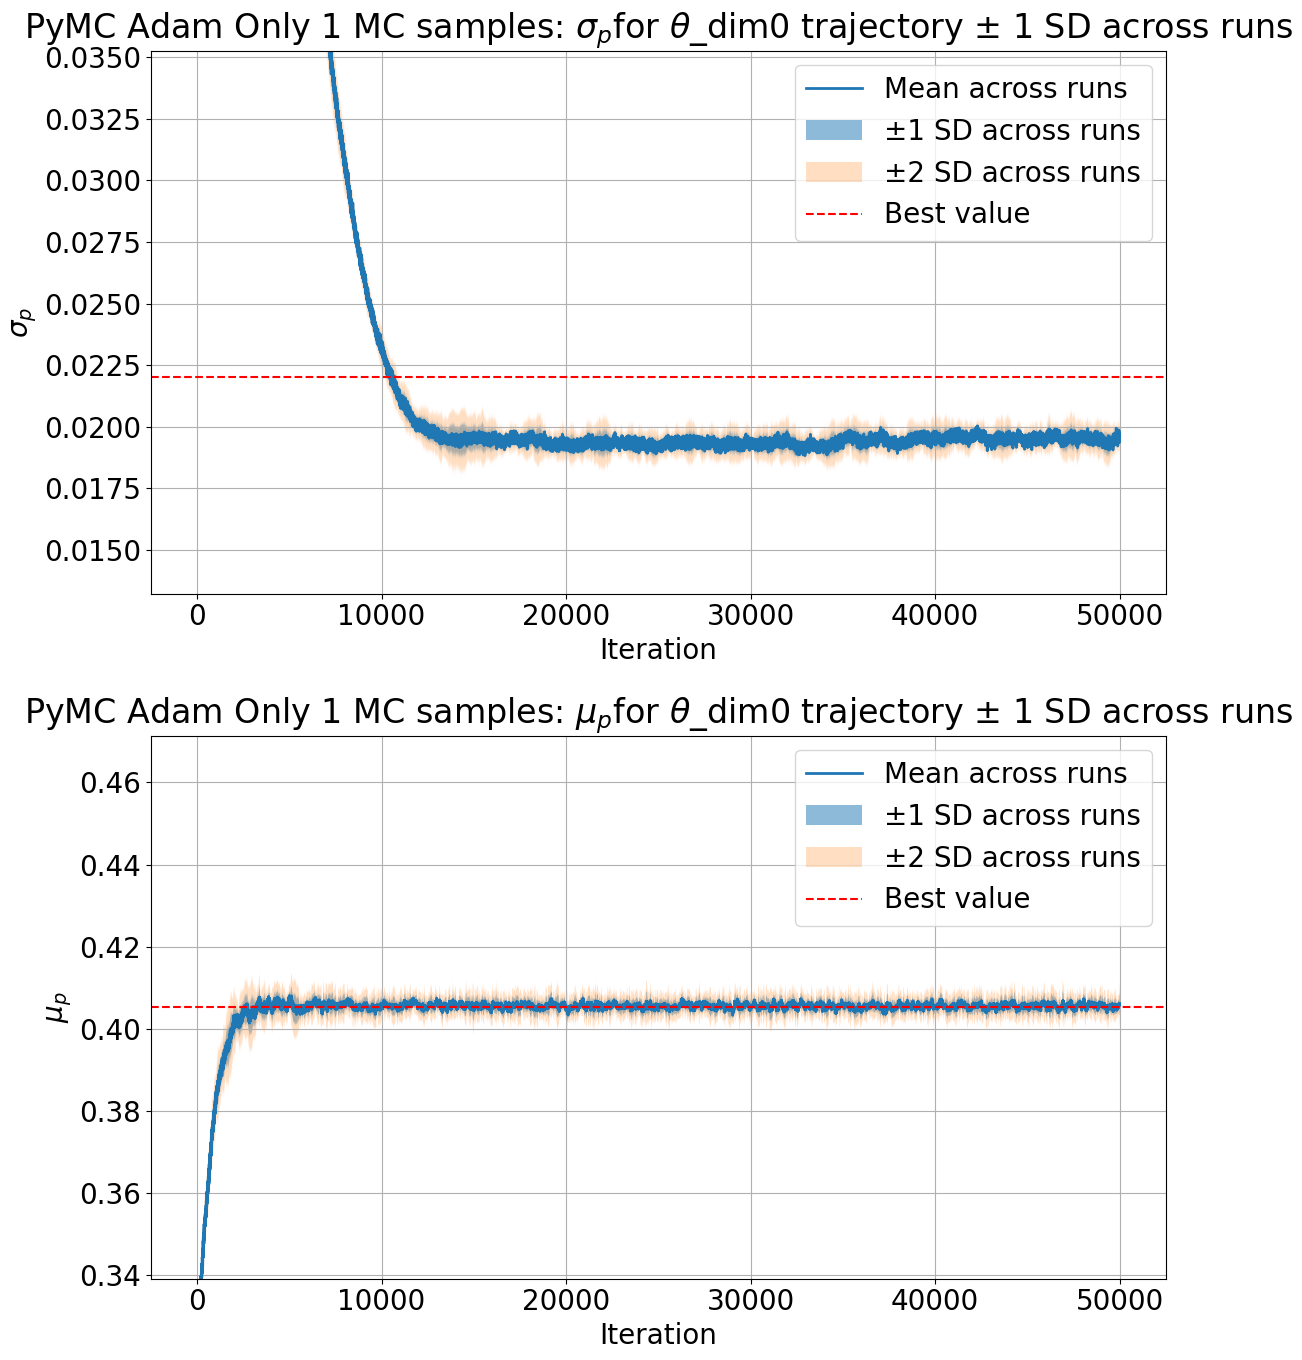

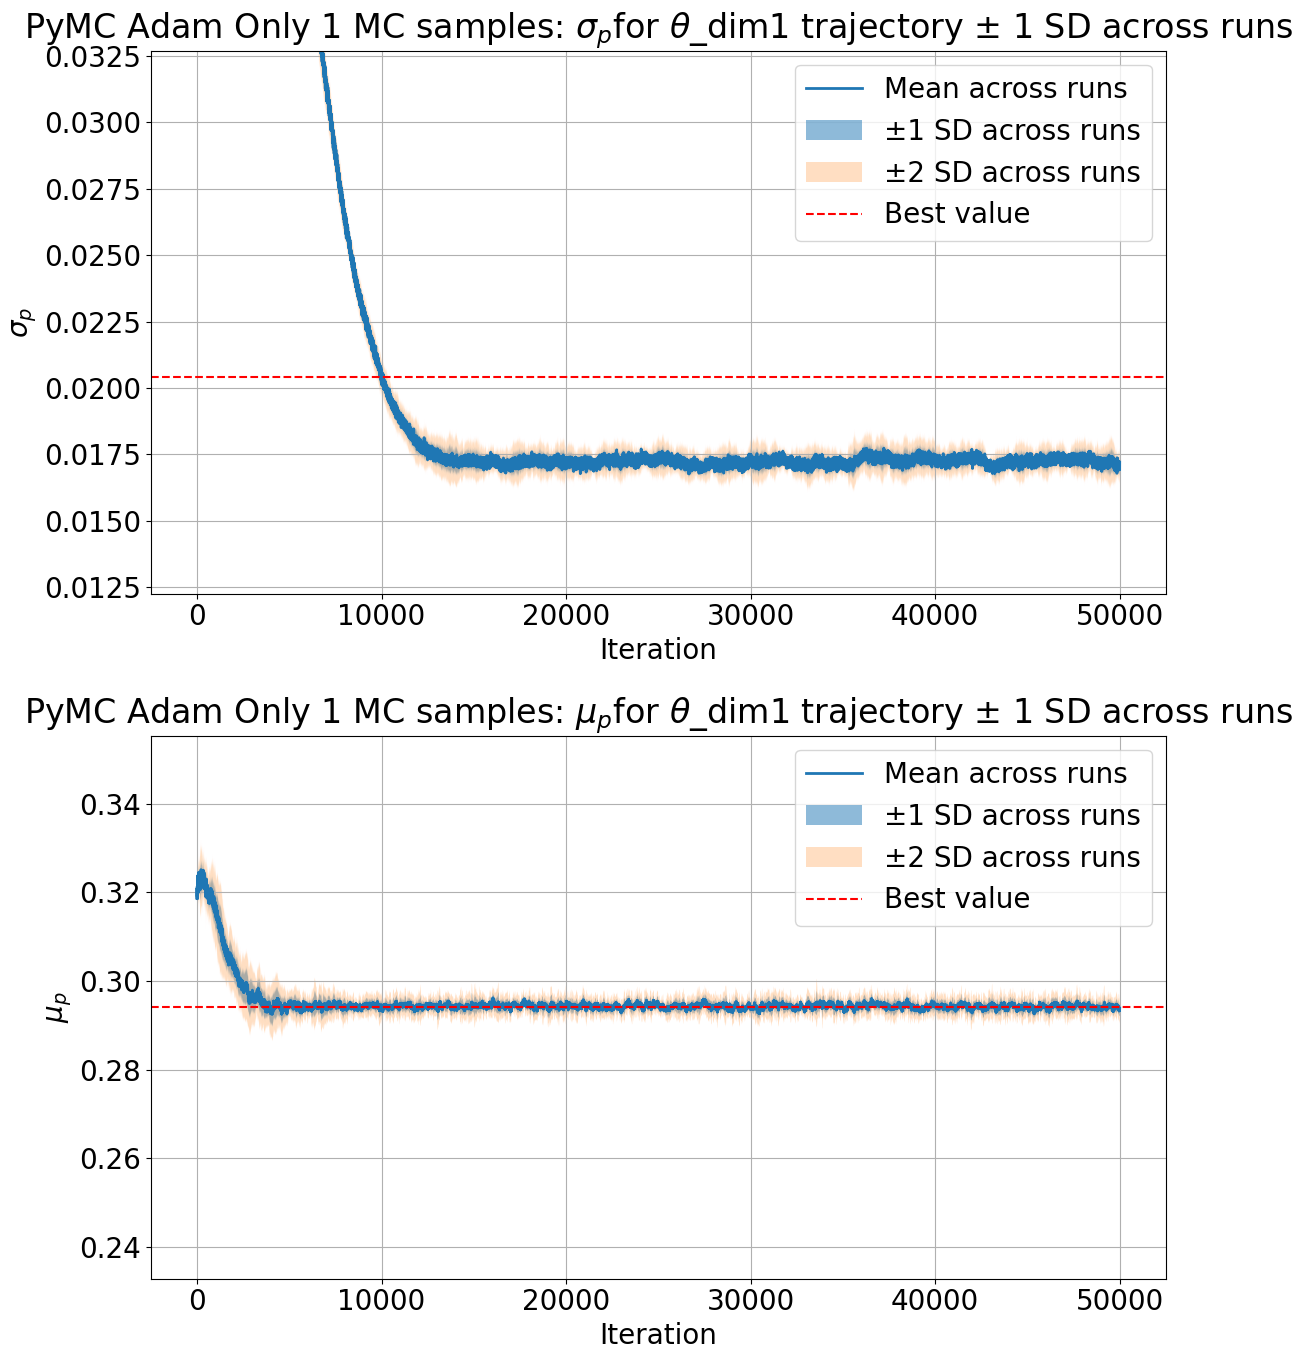

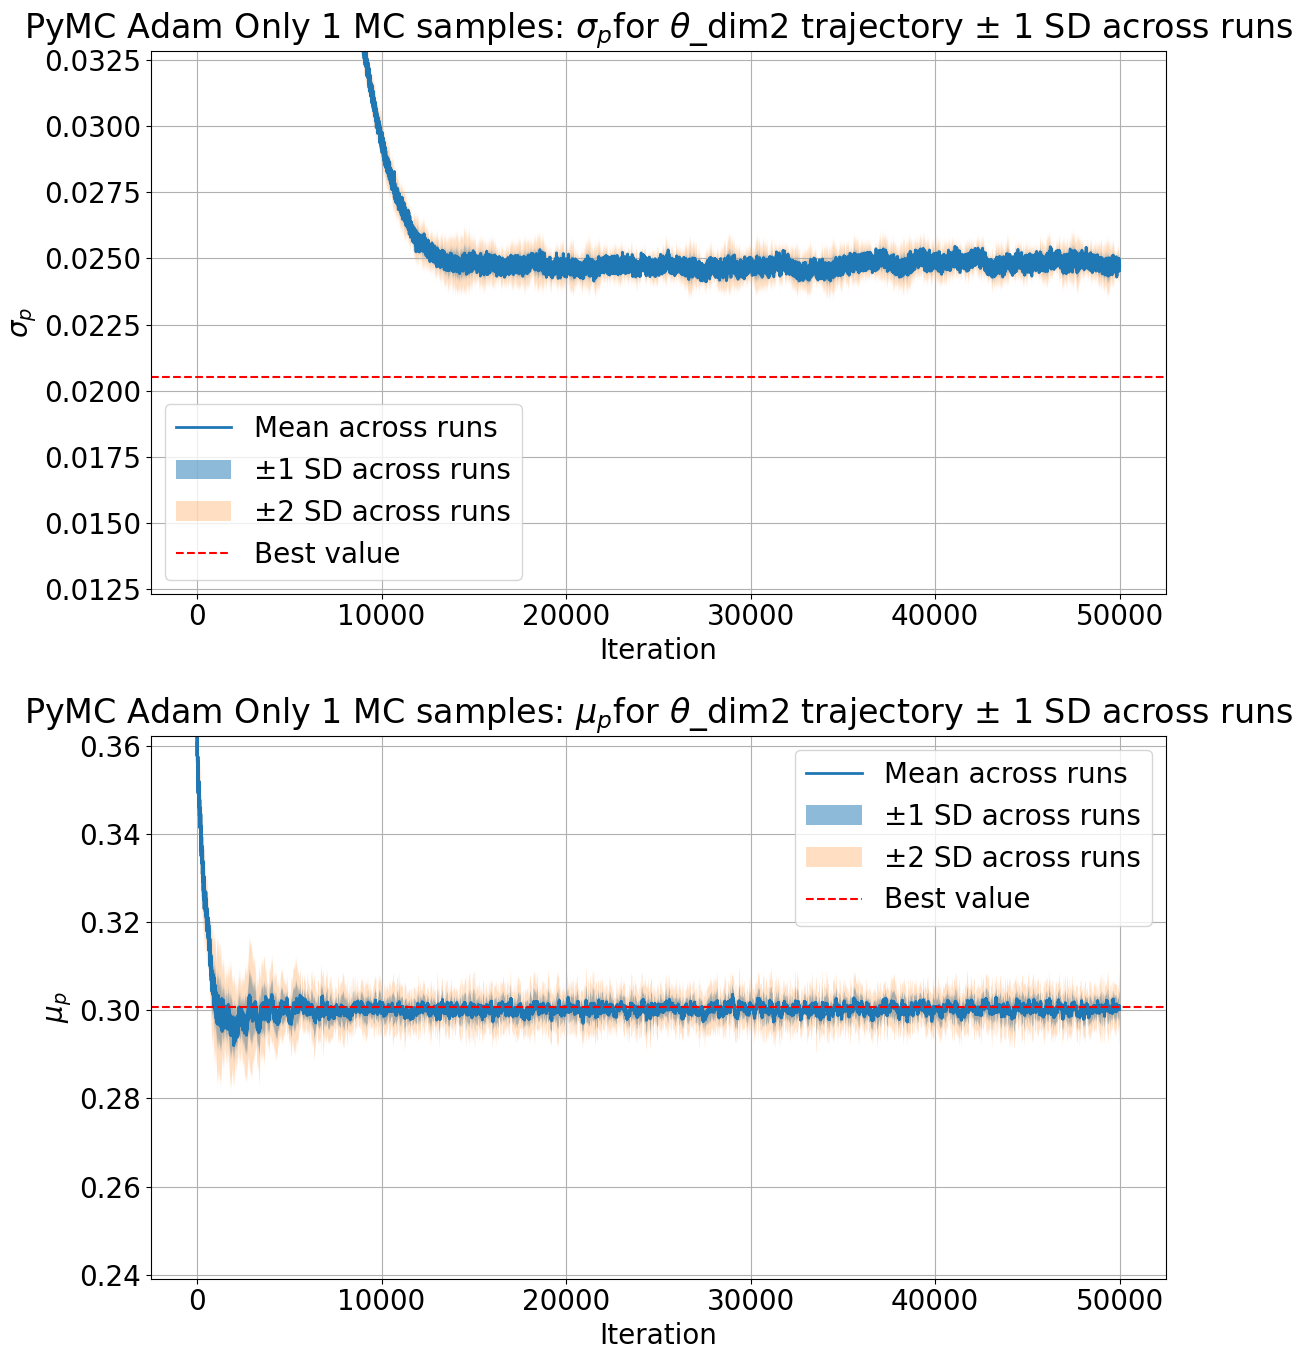

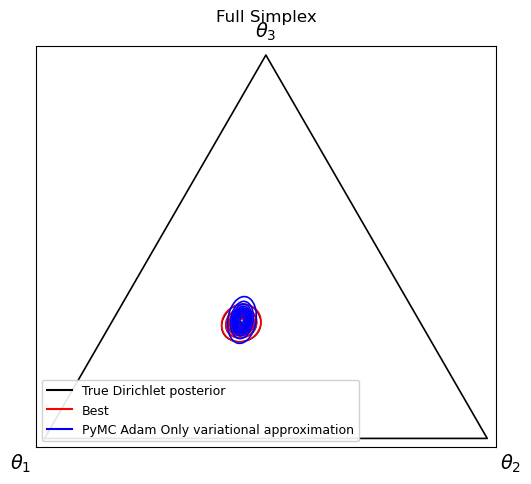

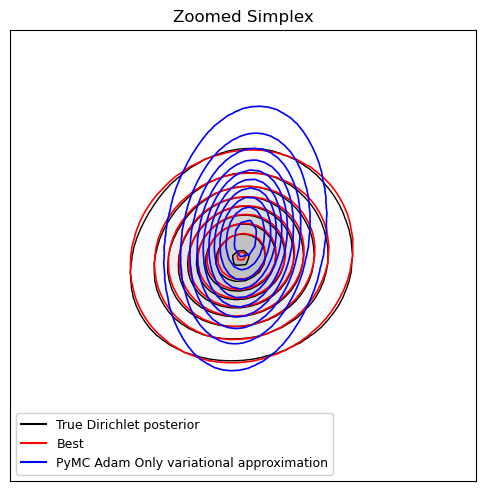

18.450834
18.446516
18.45512
18.422346
18.479652
18.436775
18.468285
18.448156
18.486622
18.431587


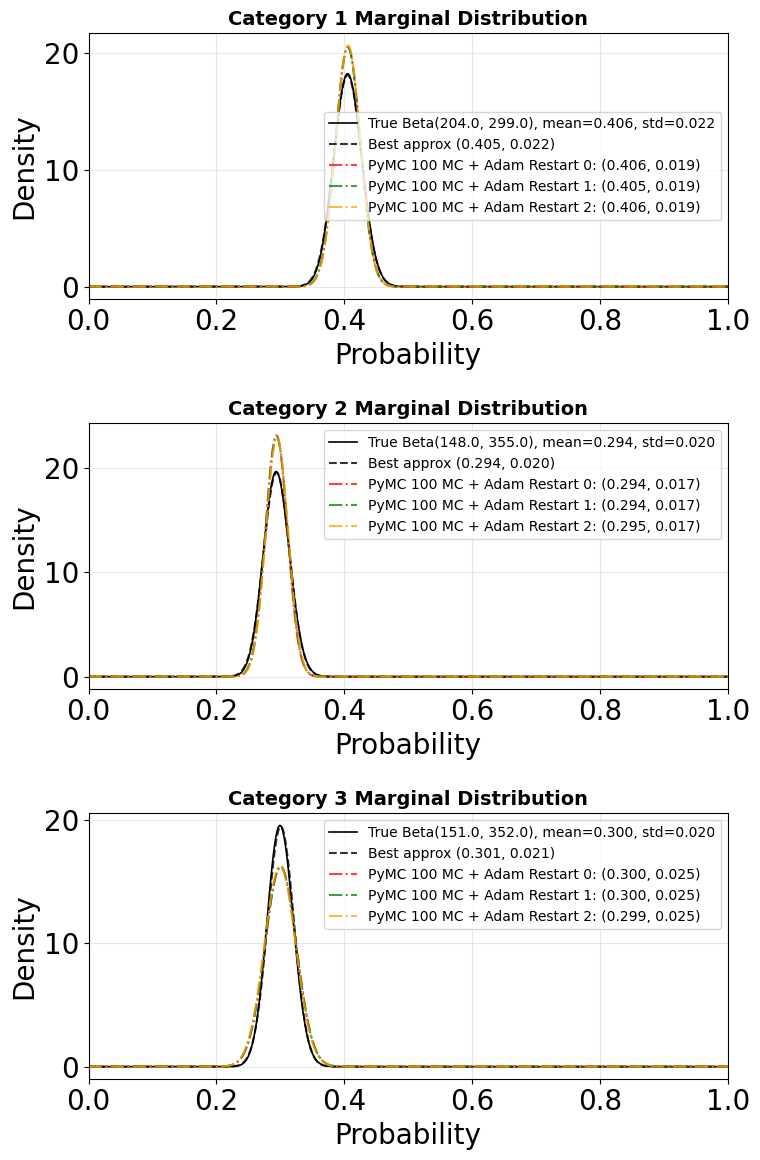

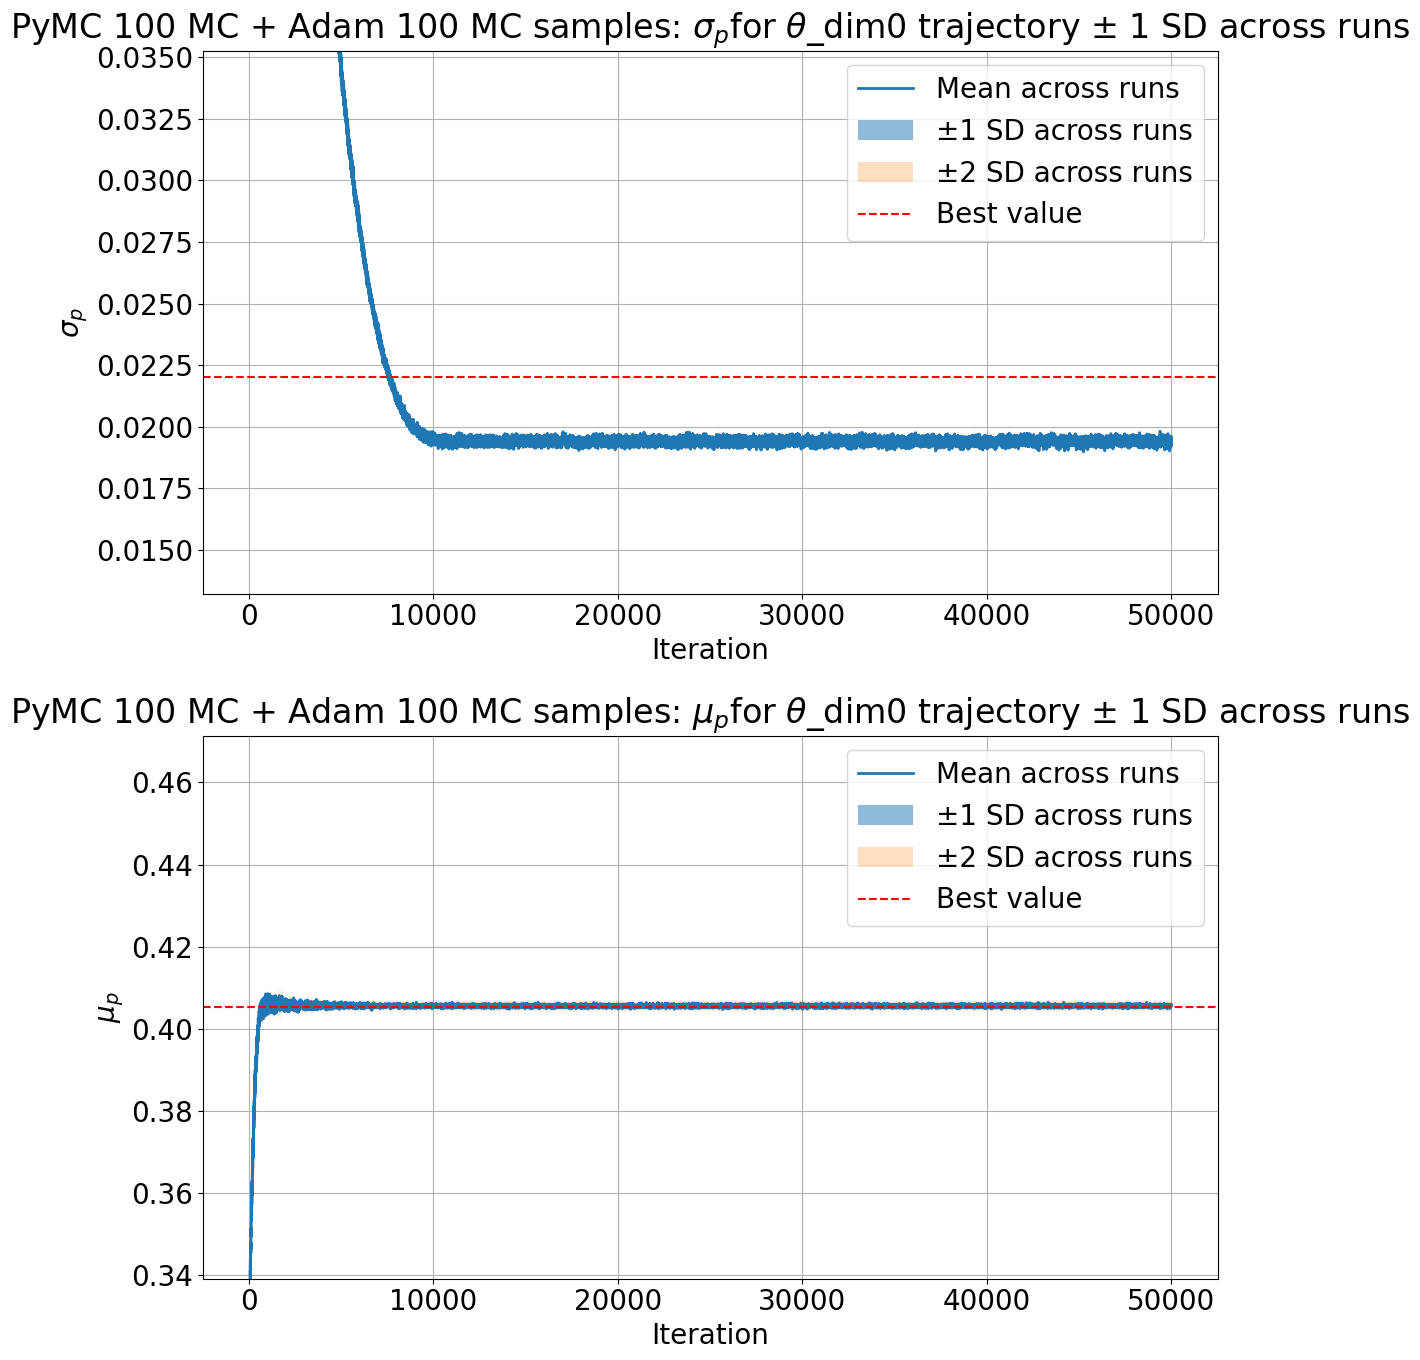

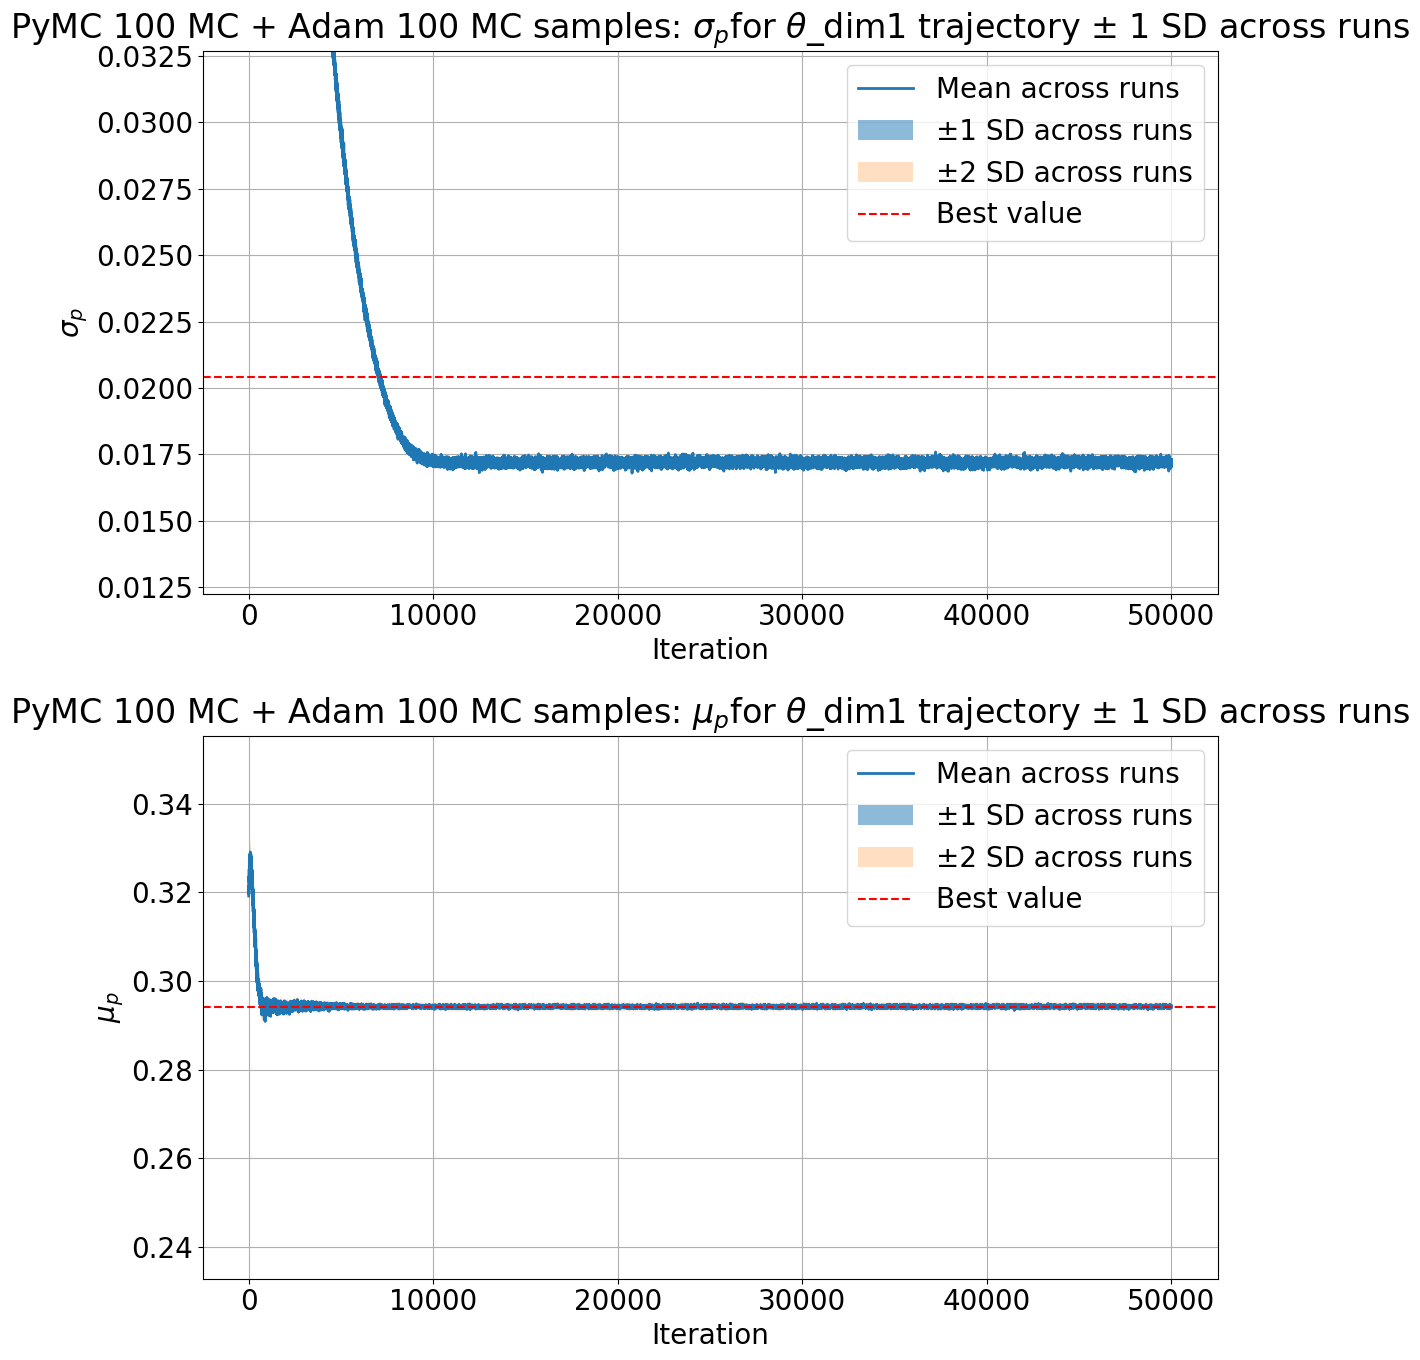

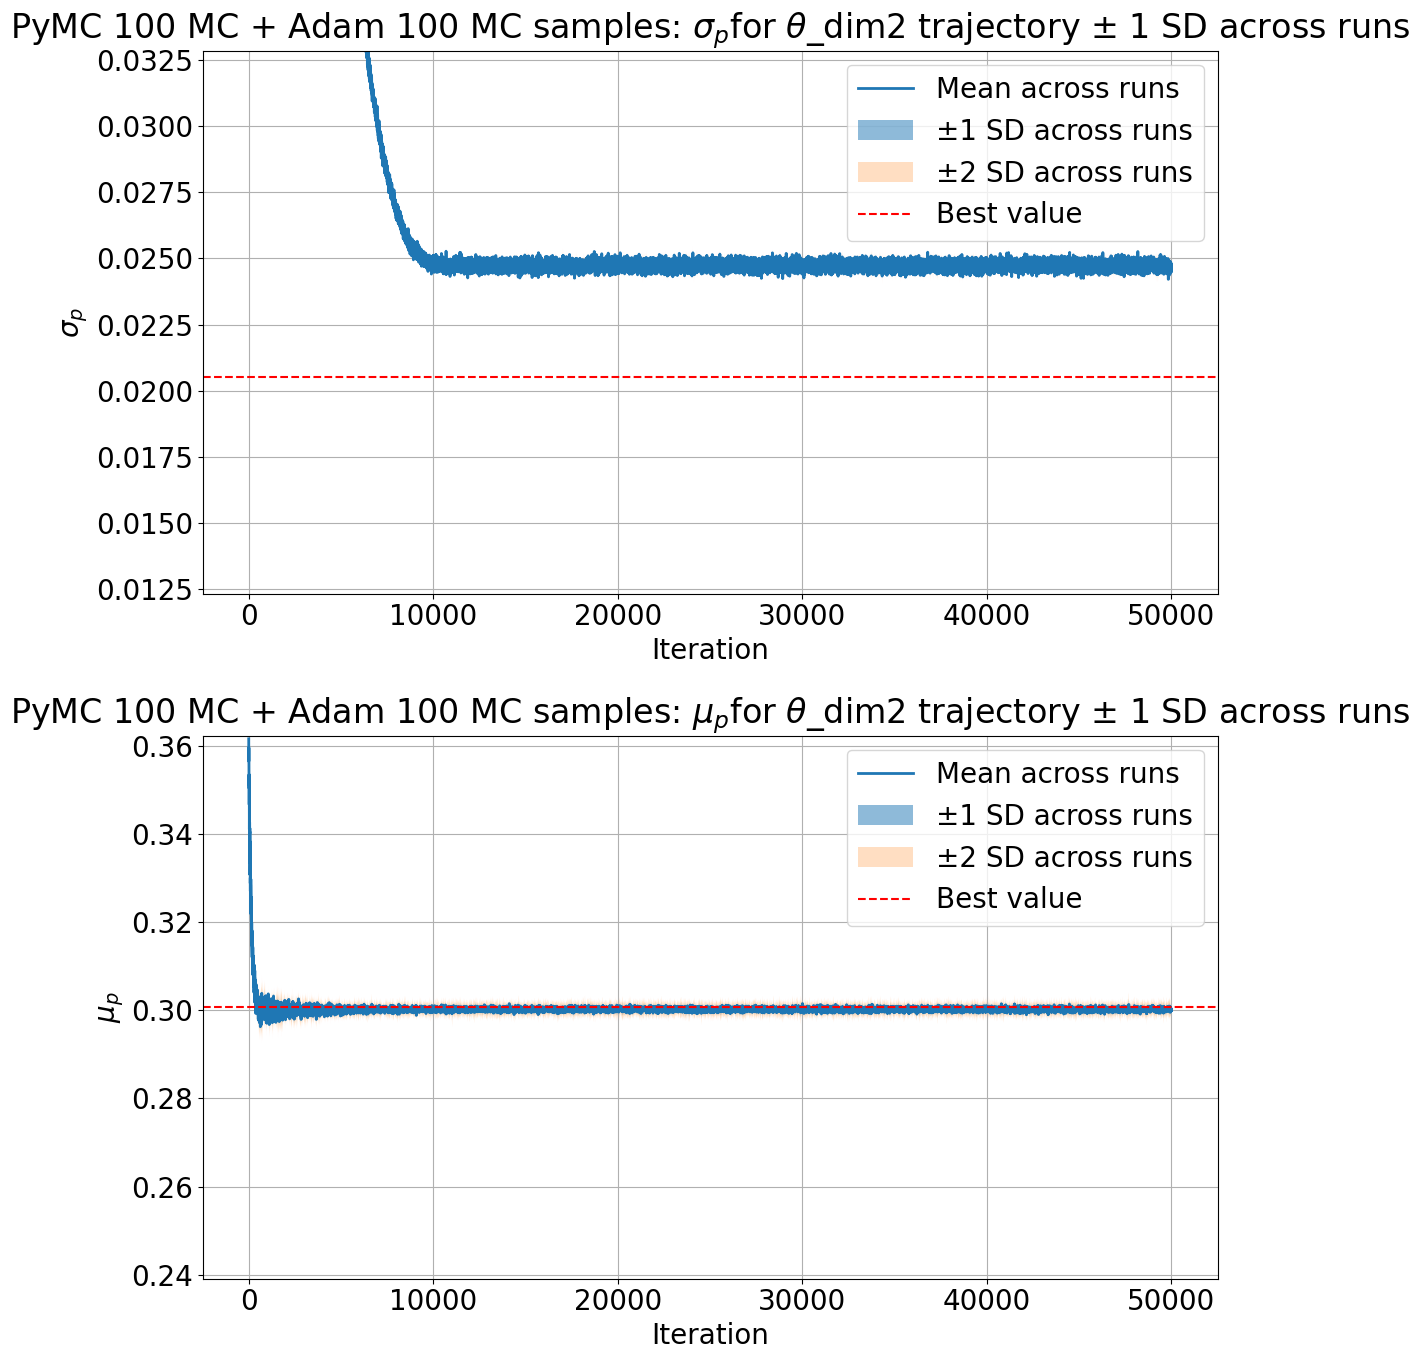

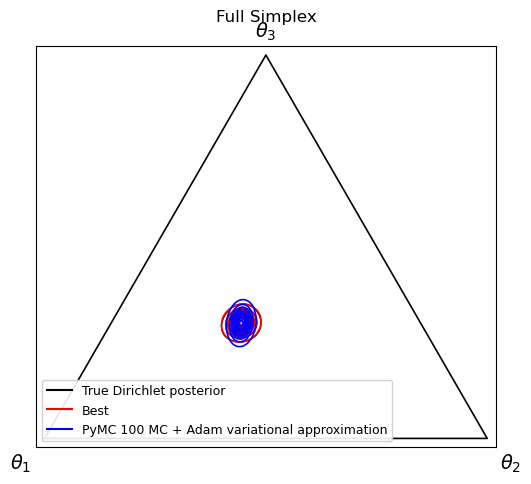

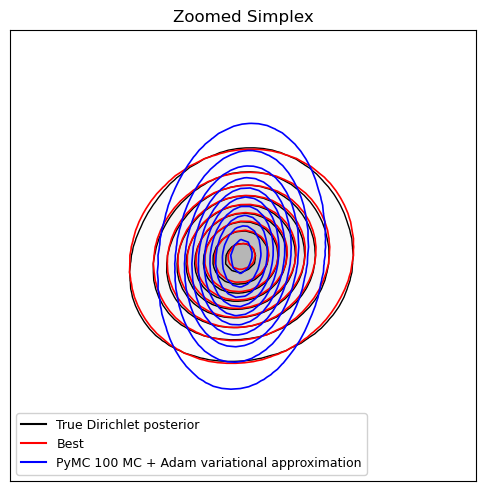

18.162819
18.13127
18.139336
18.155005
18.165705
18.18442
18.1811
18.164982
18.191175
18.175875


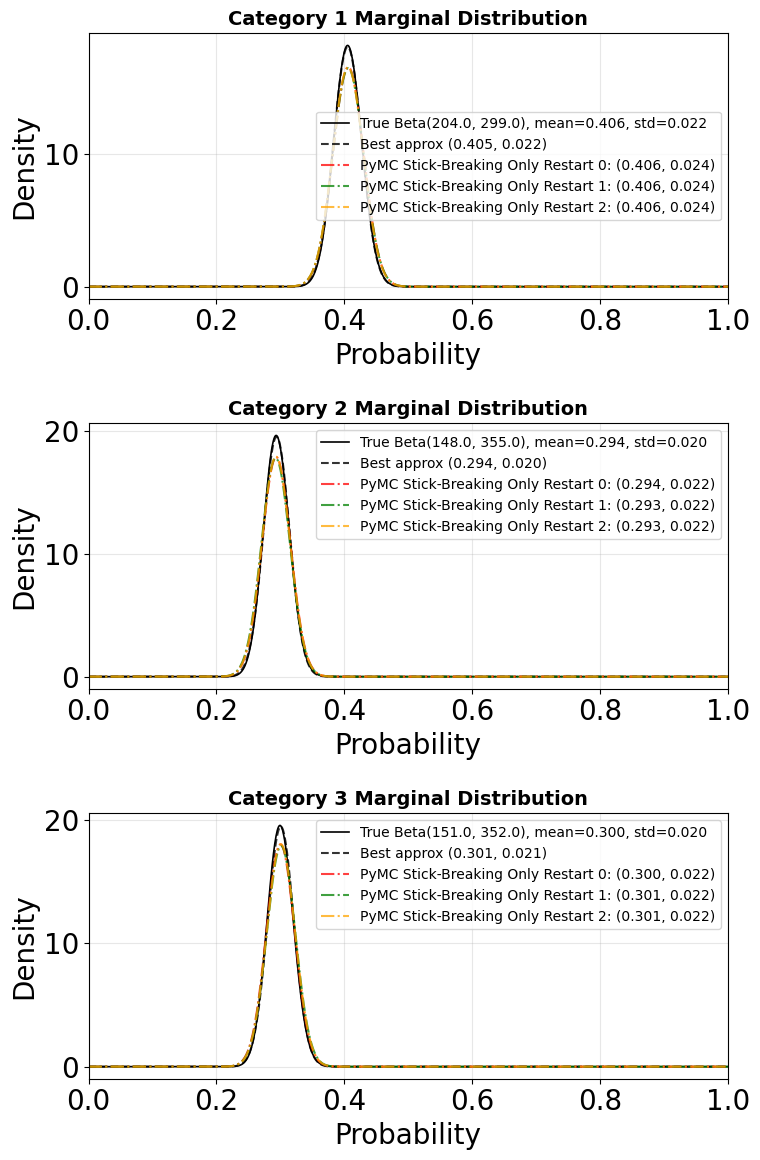

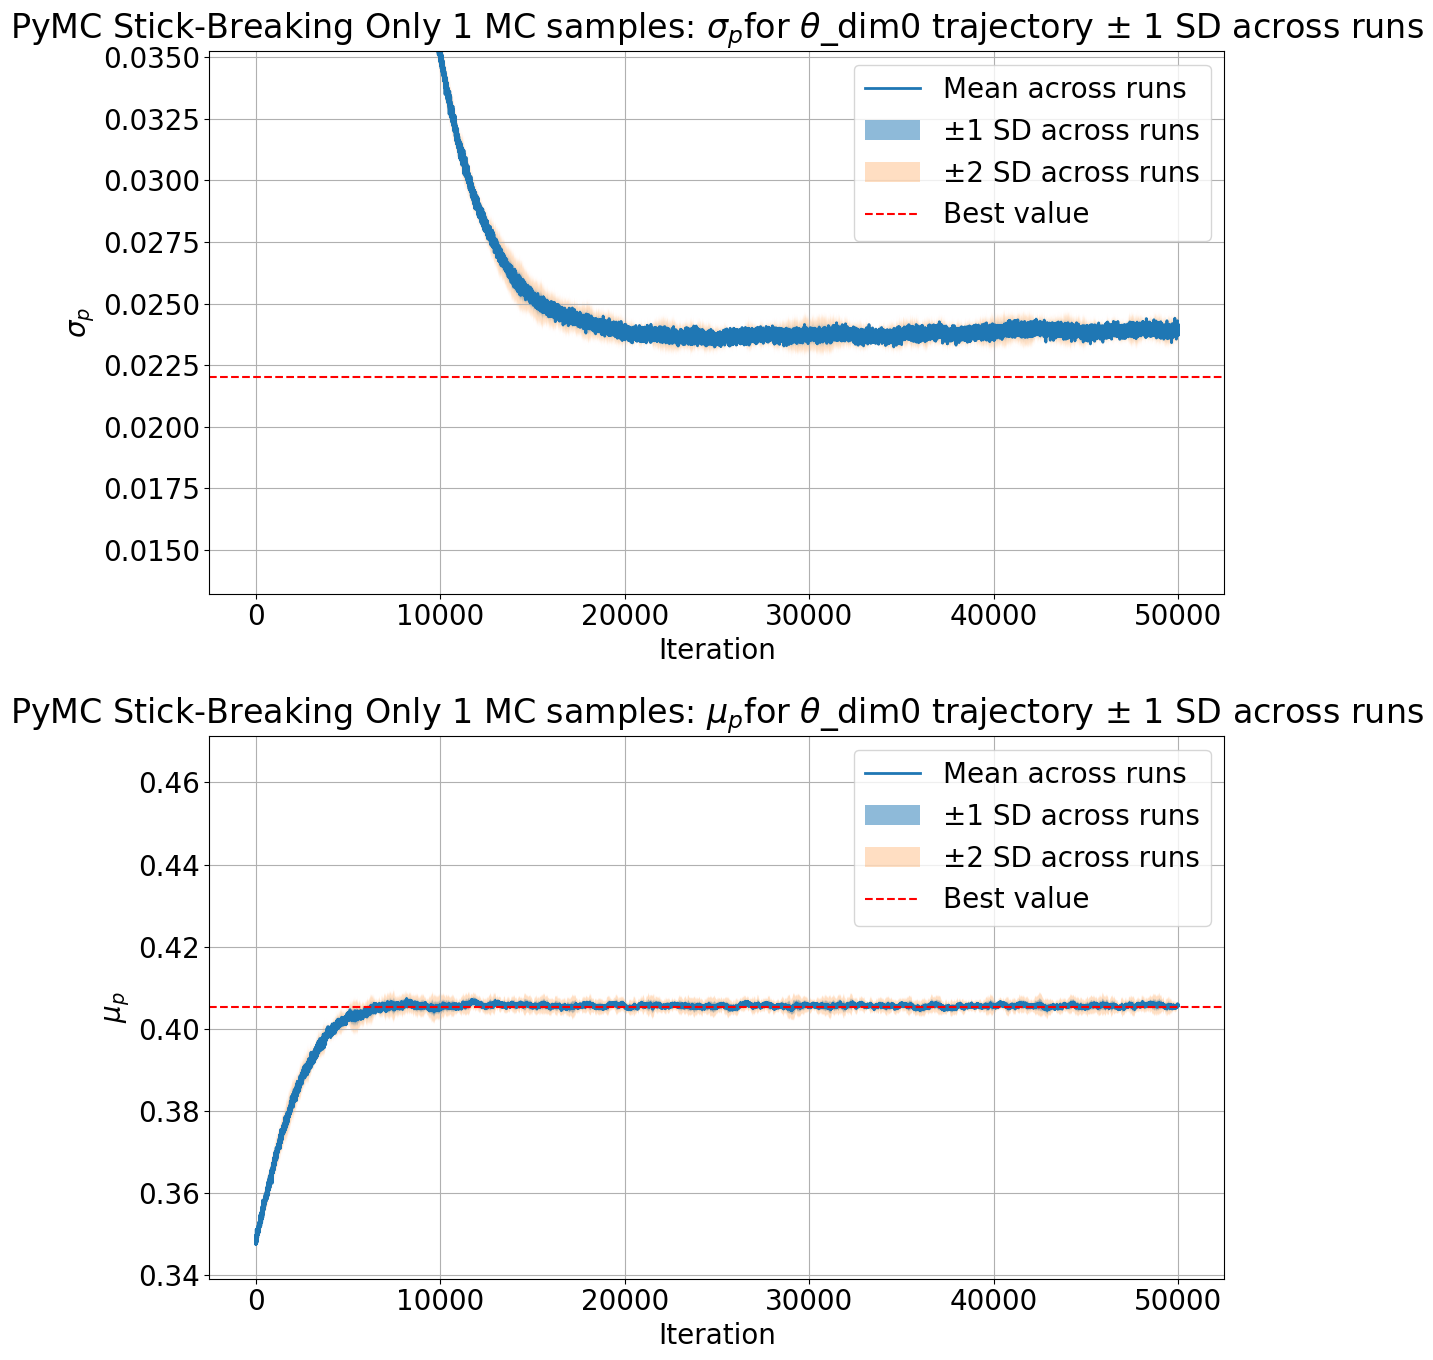

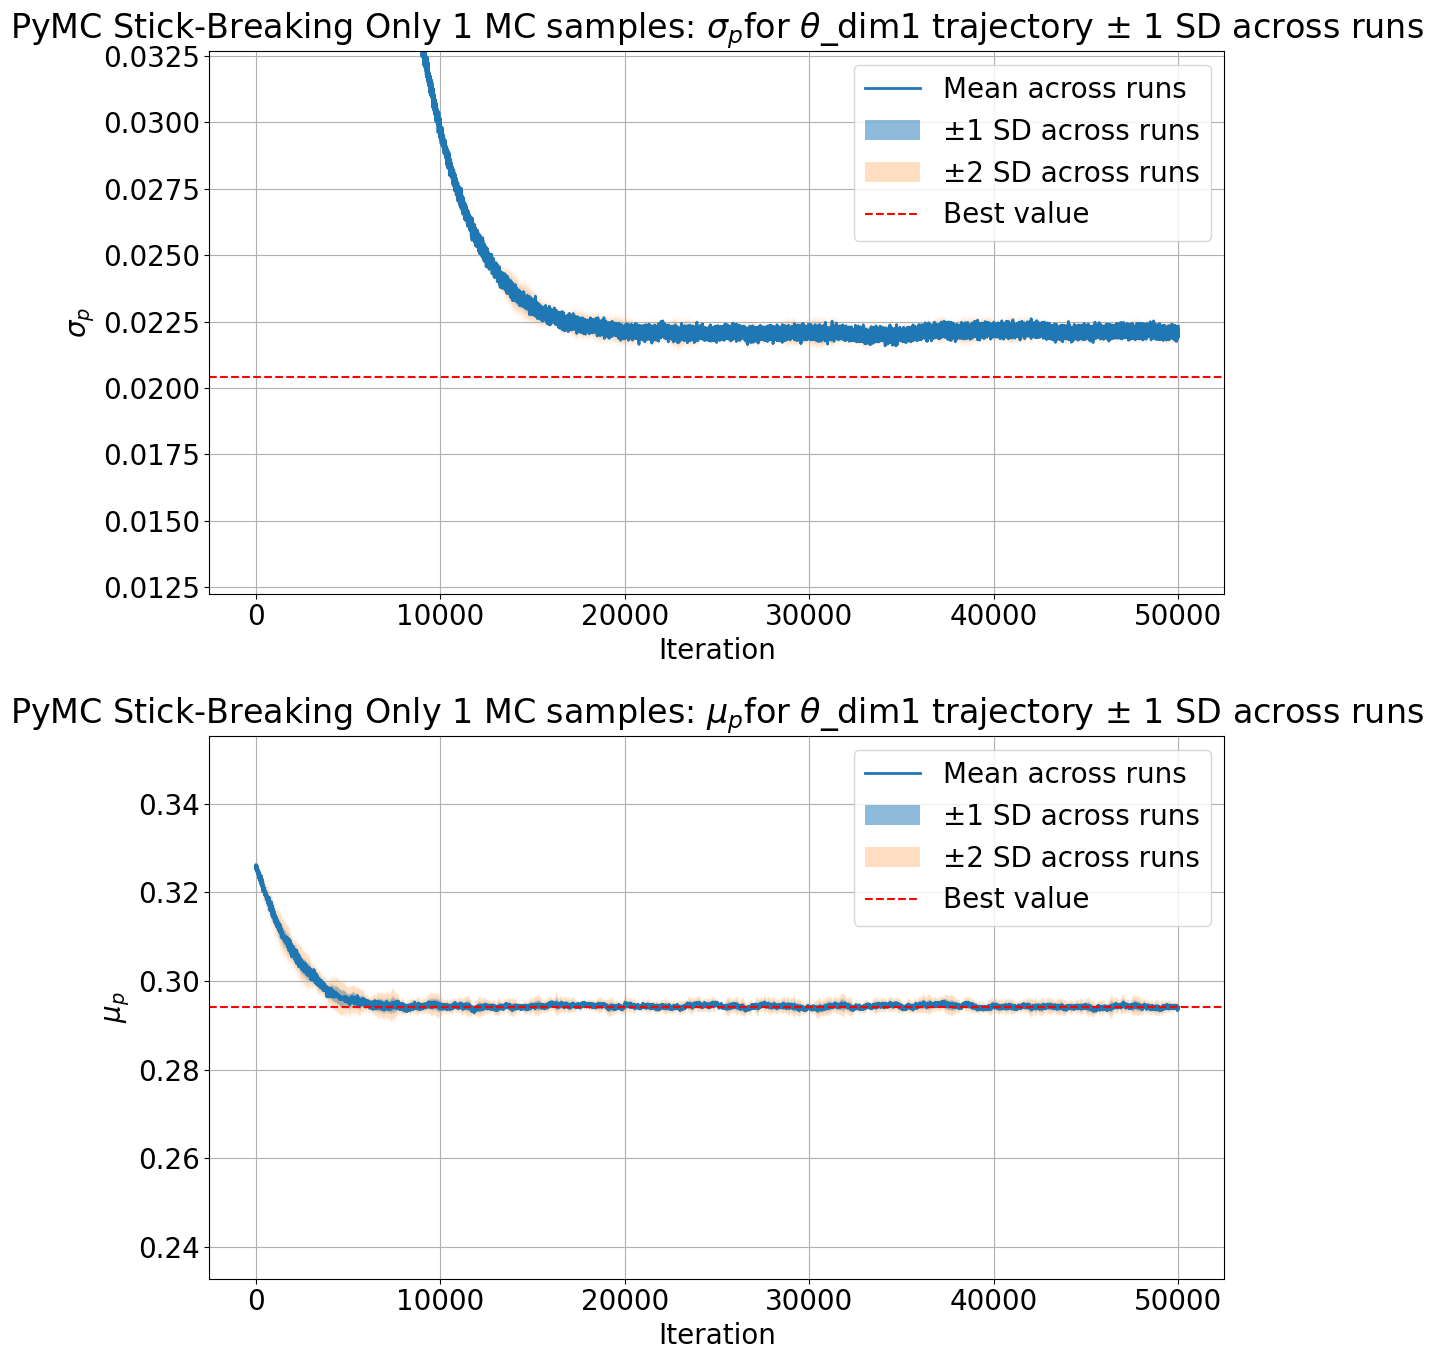

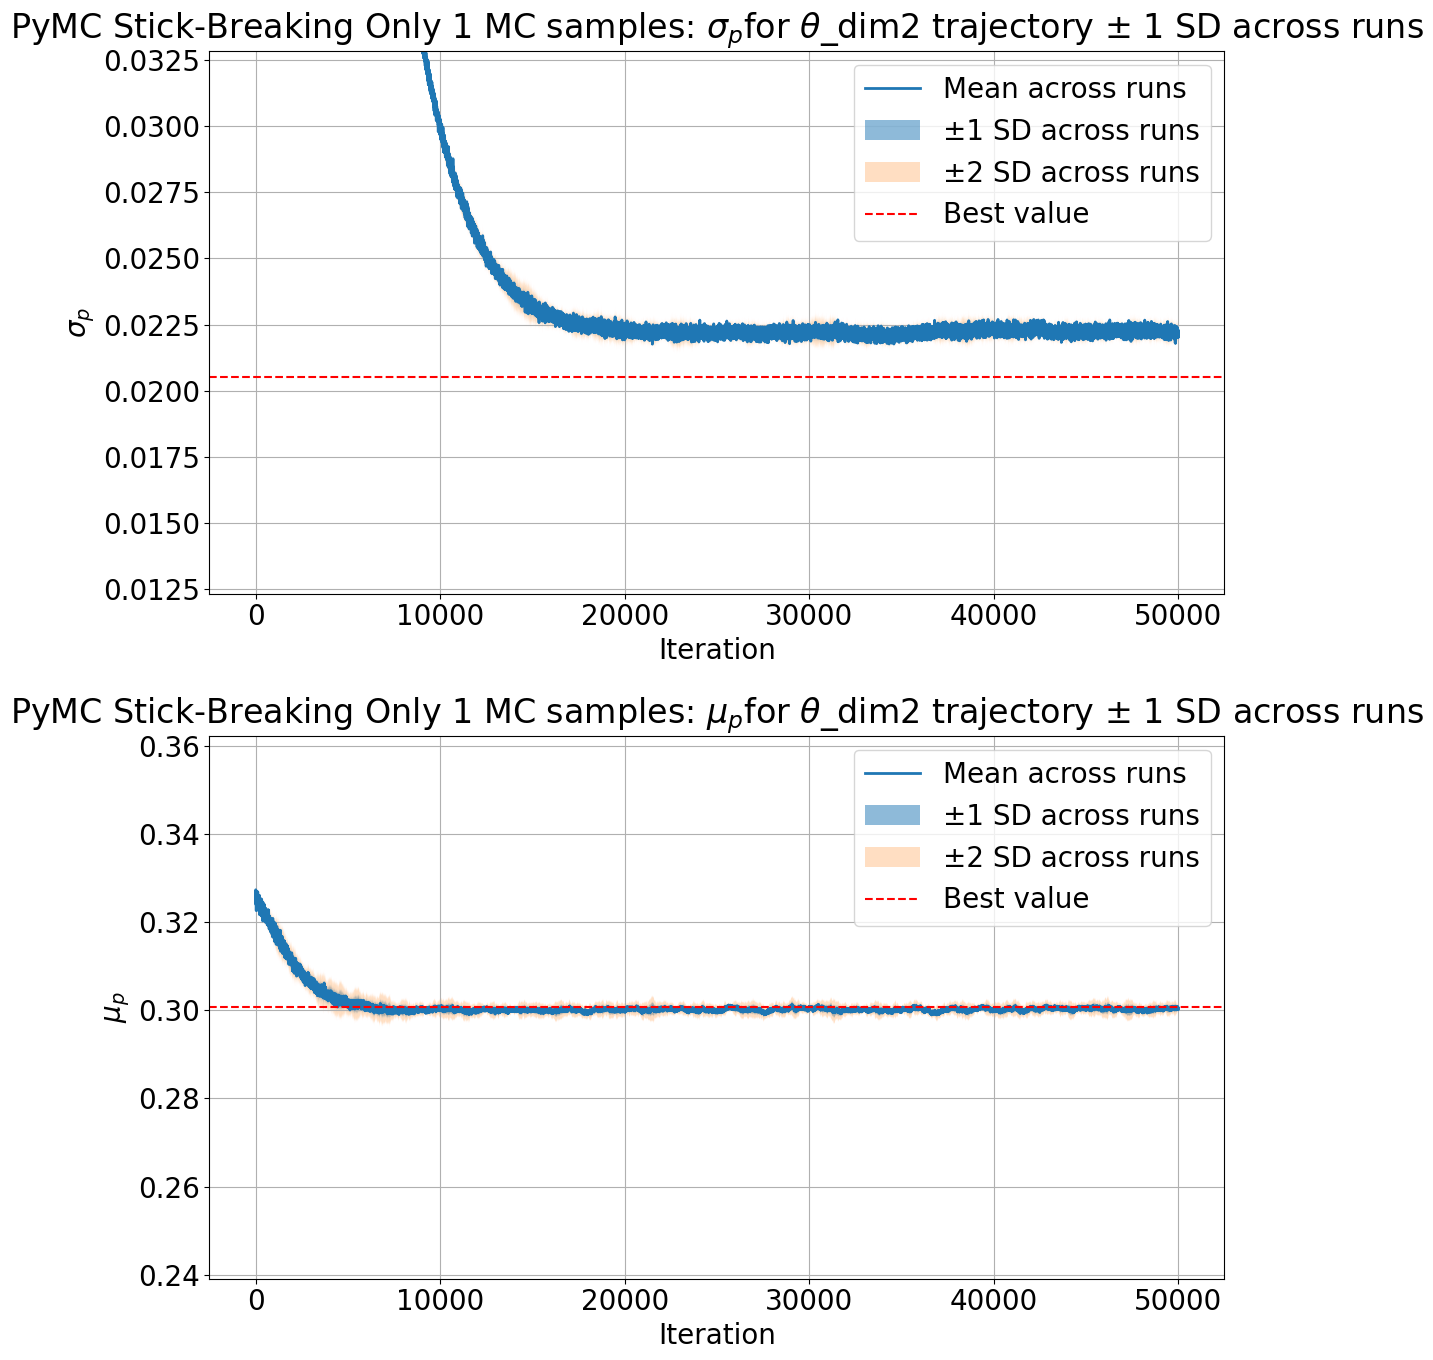

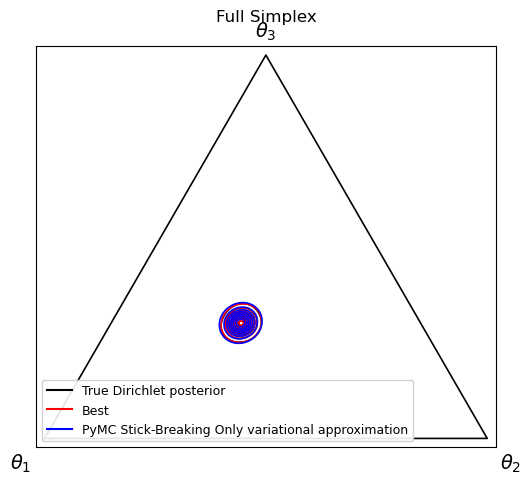

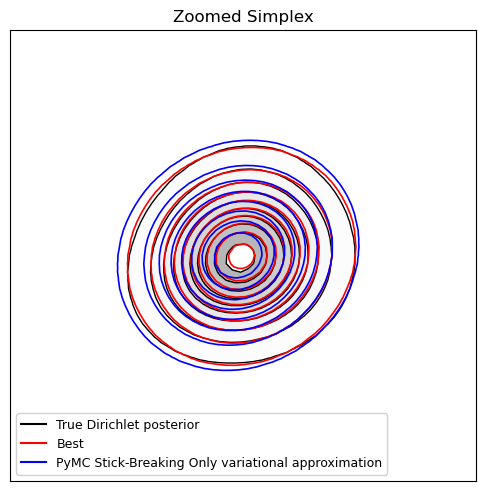

18.331425
18.332197
18.328041
18.327633
18.344202
18.327948
18.339657
18.3356
18.36395
18.328598


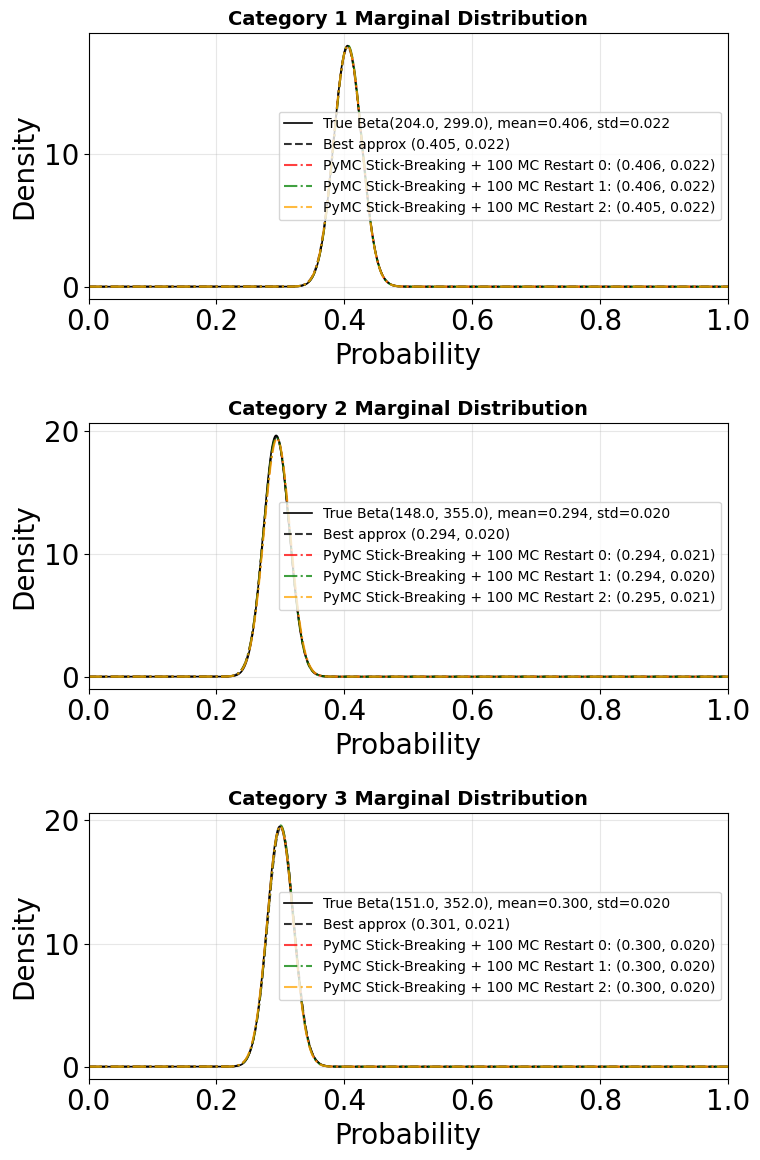

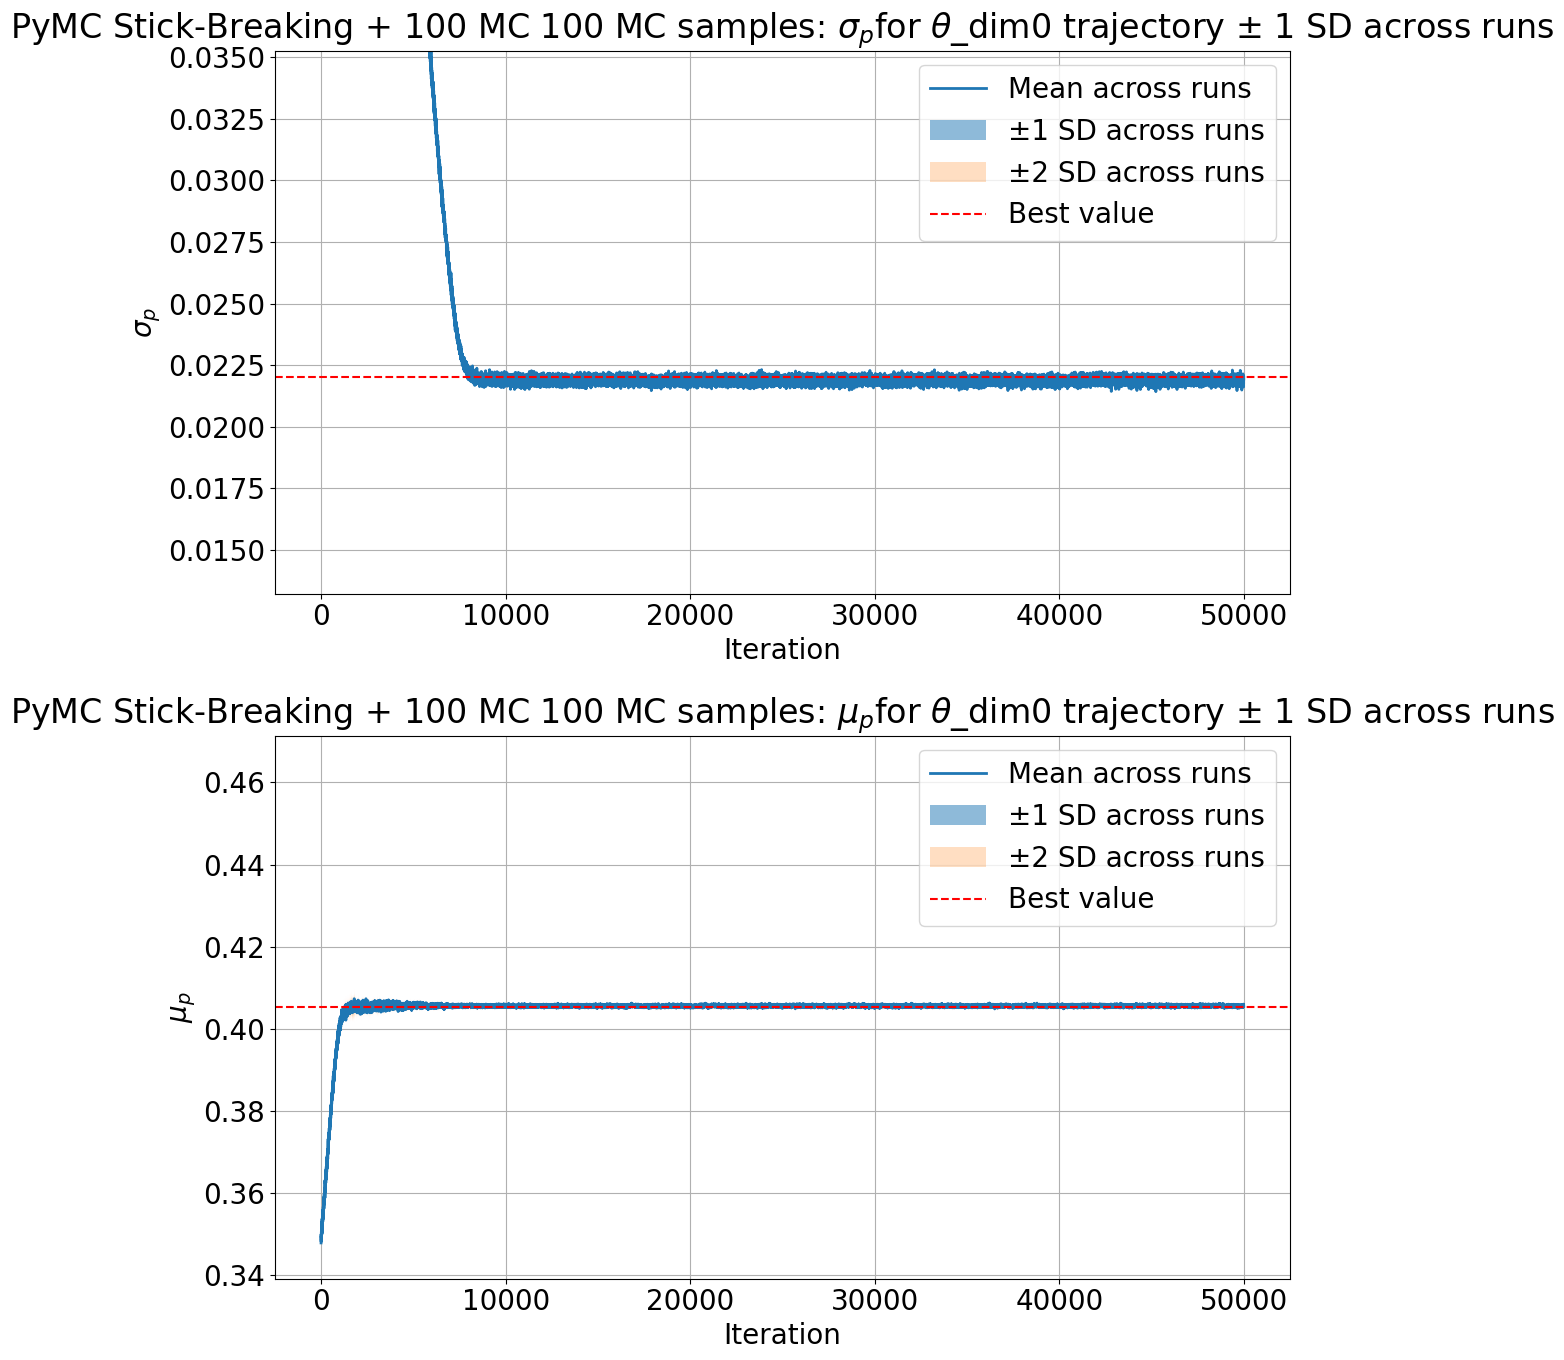

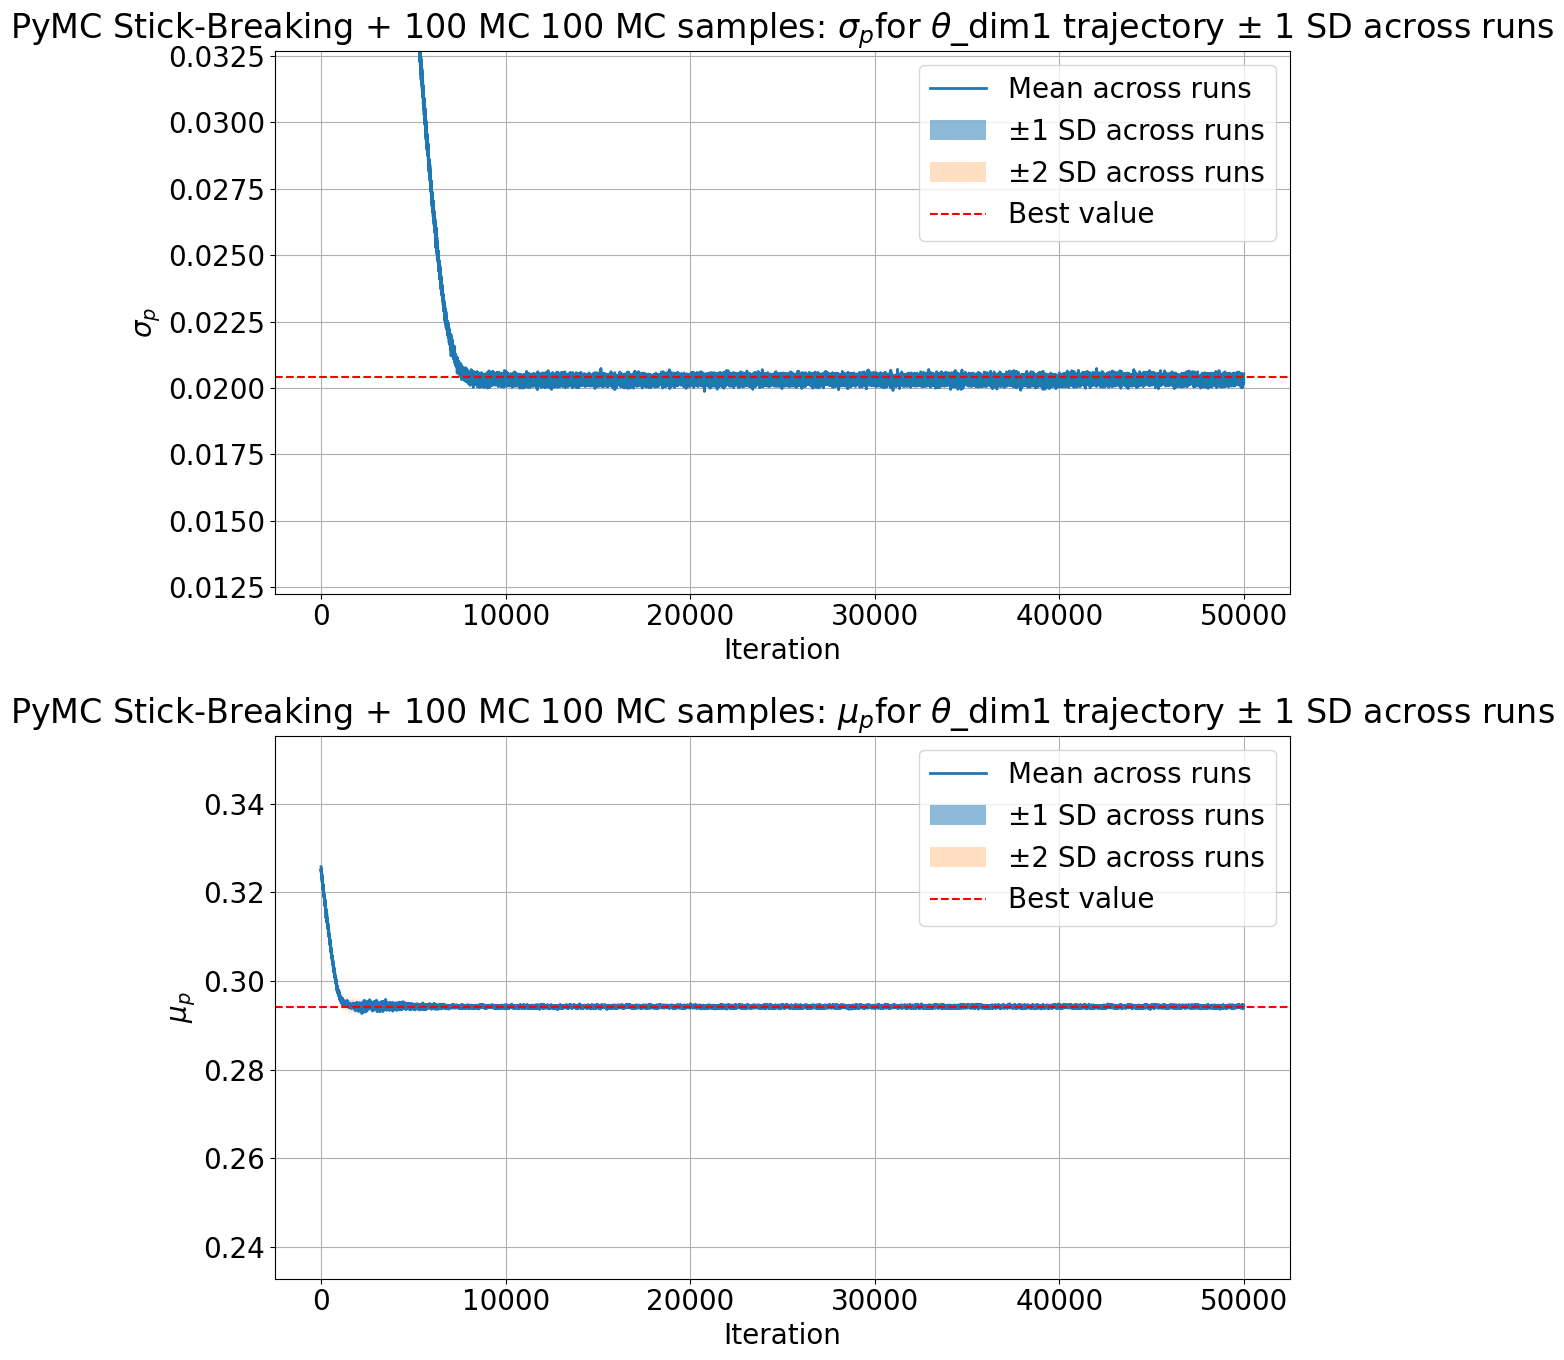

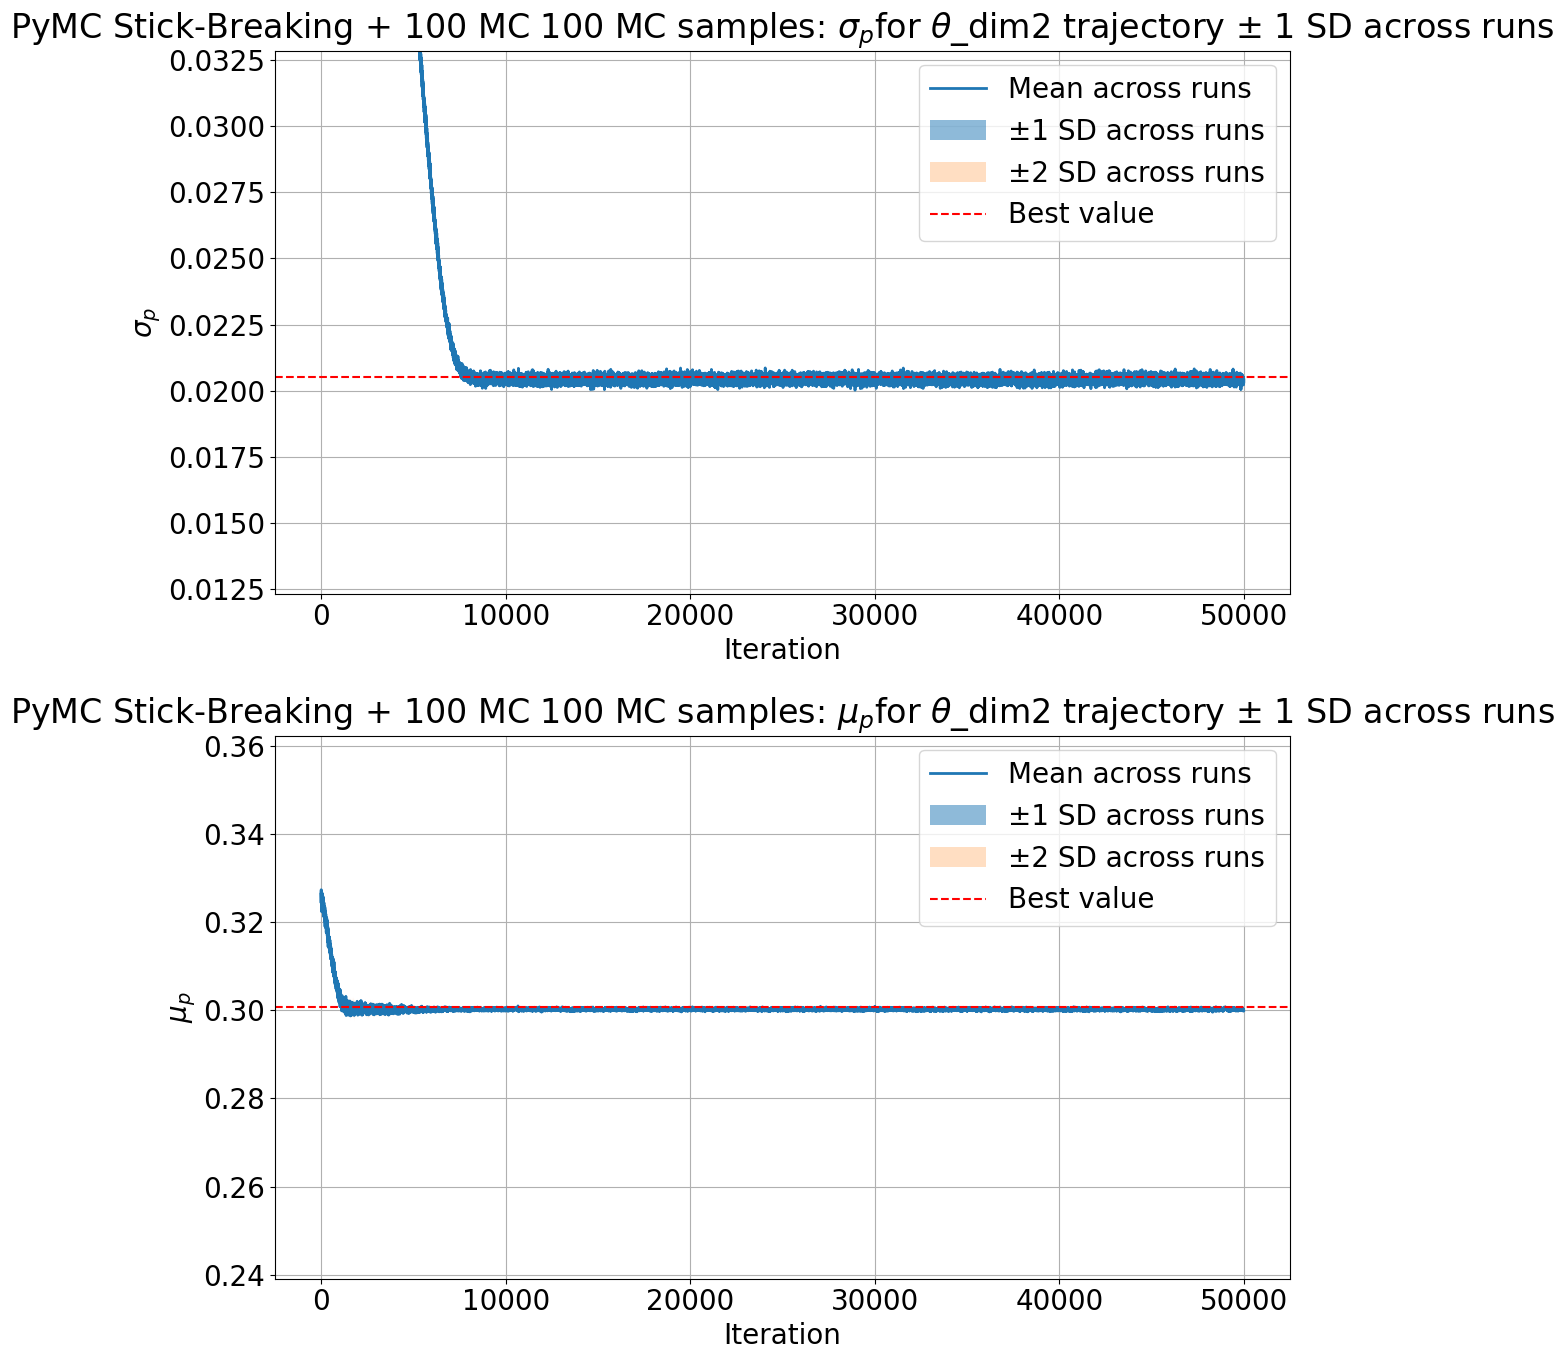

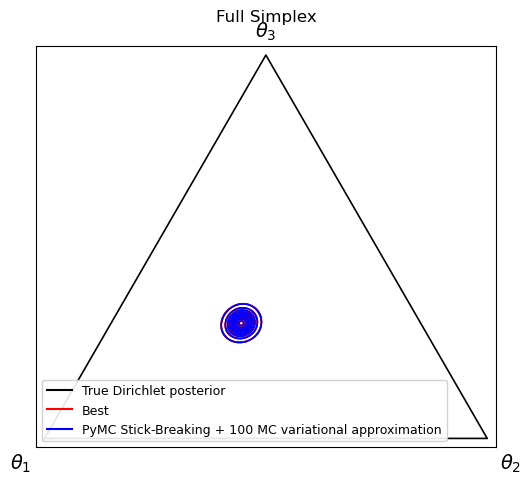

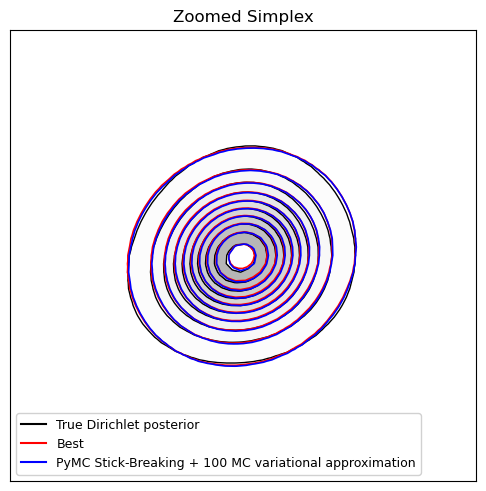

18.320623
18.292082
18.29482
18.324192
18.305437
18.337252
18.348867
18.315092
18.313583
18.362926


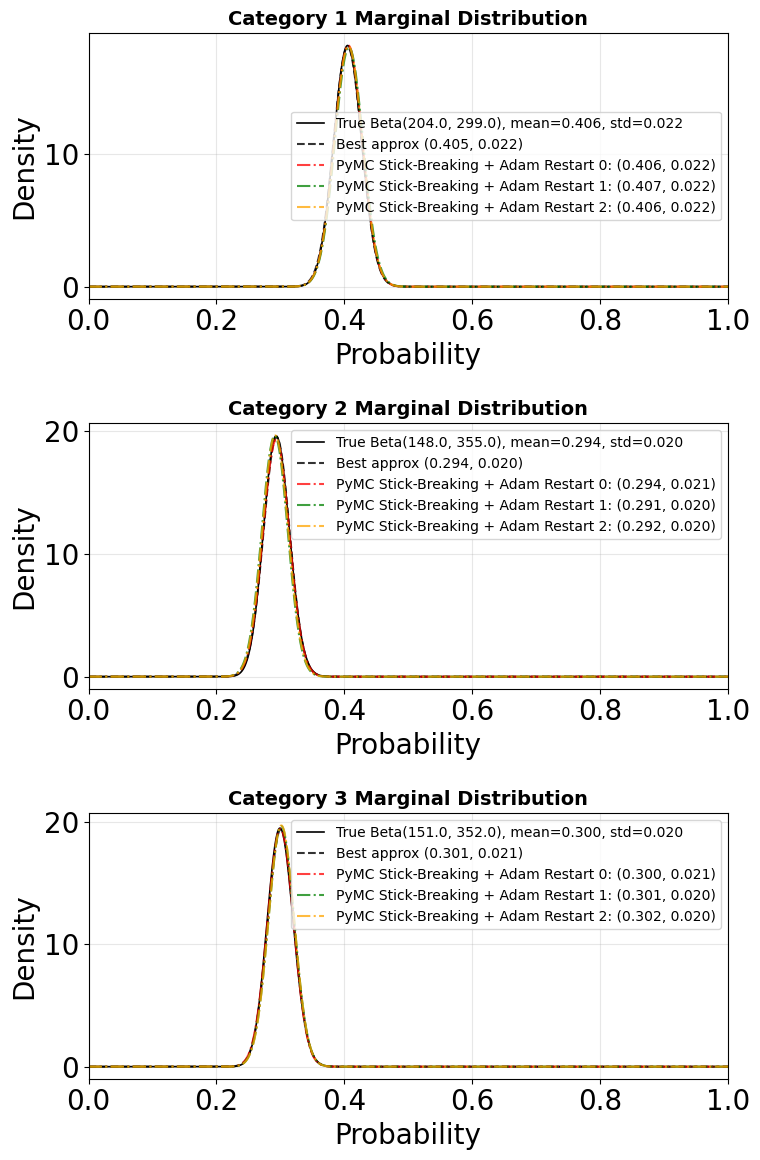

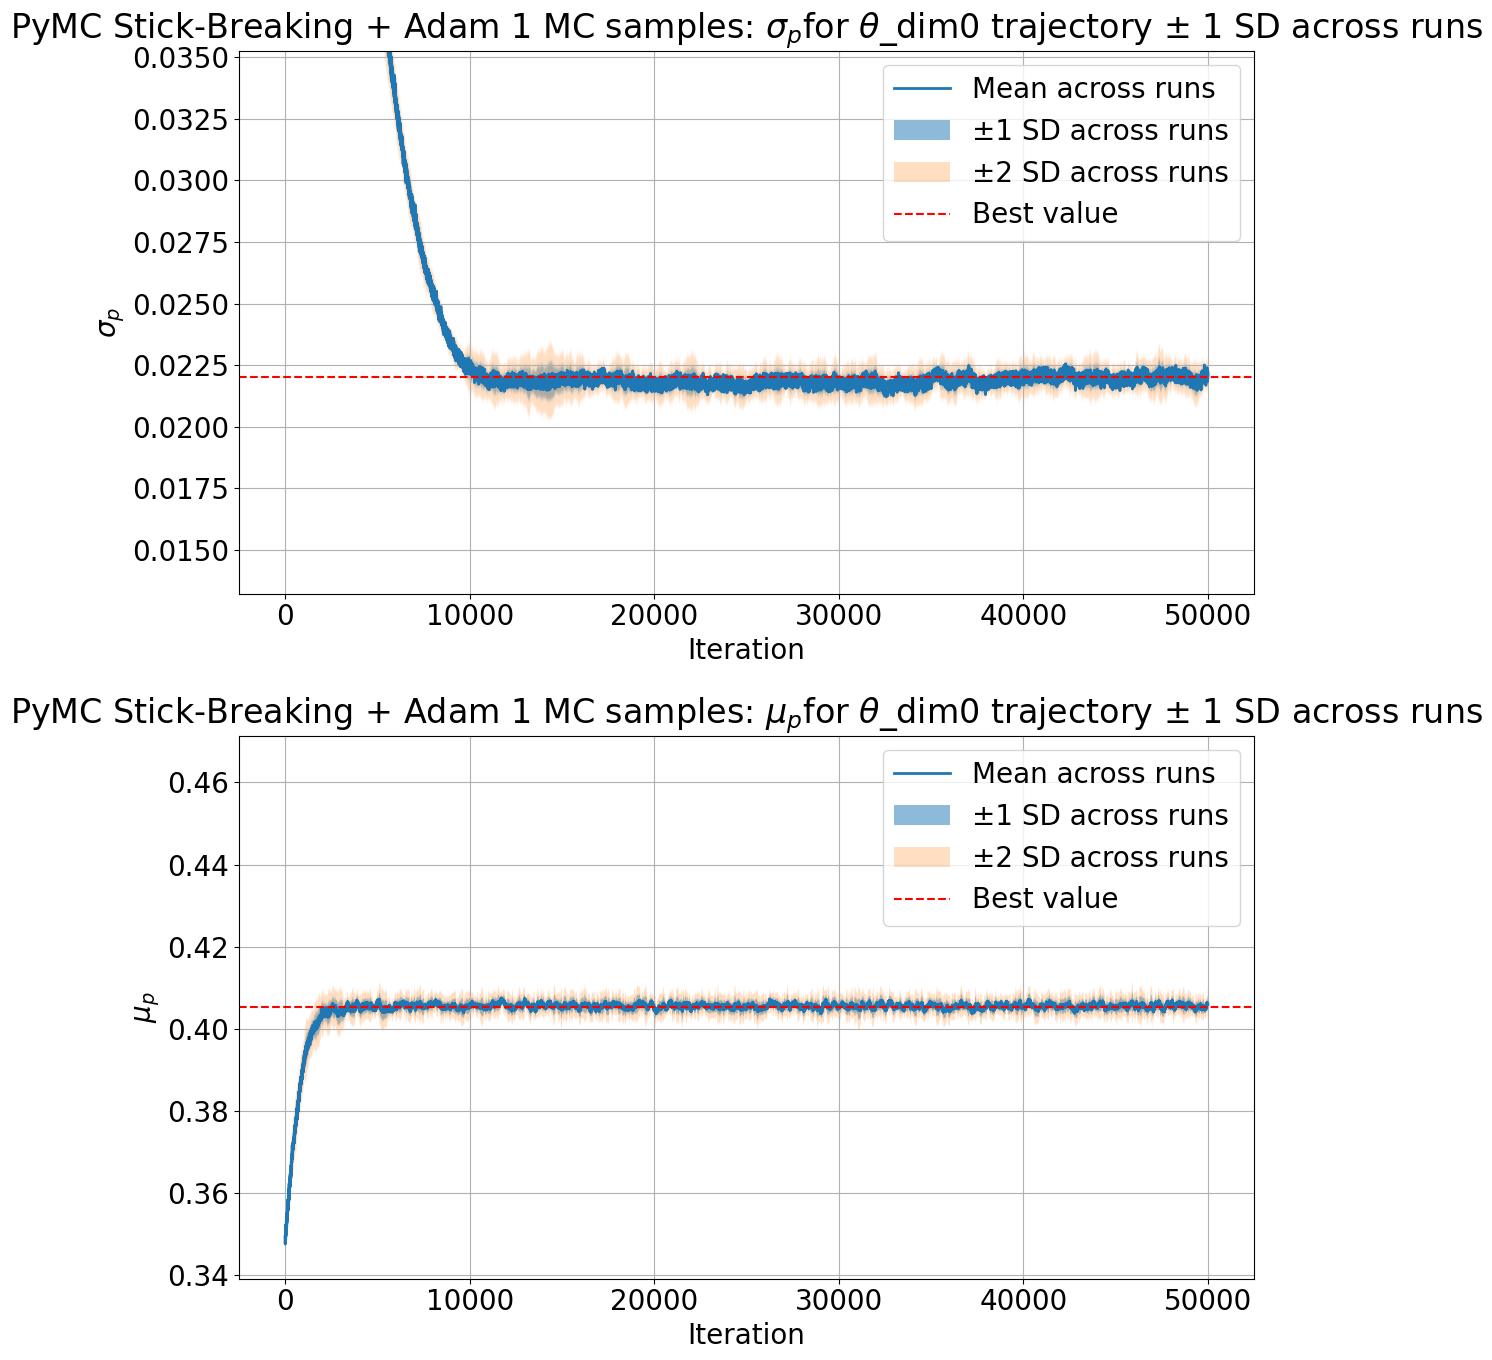

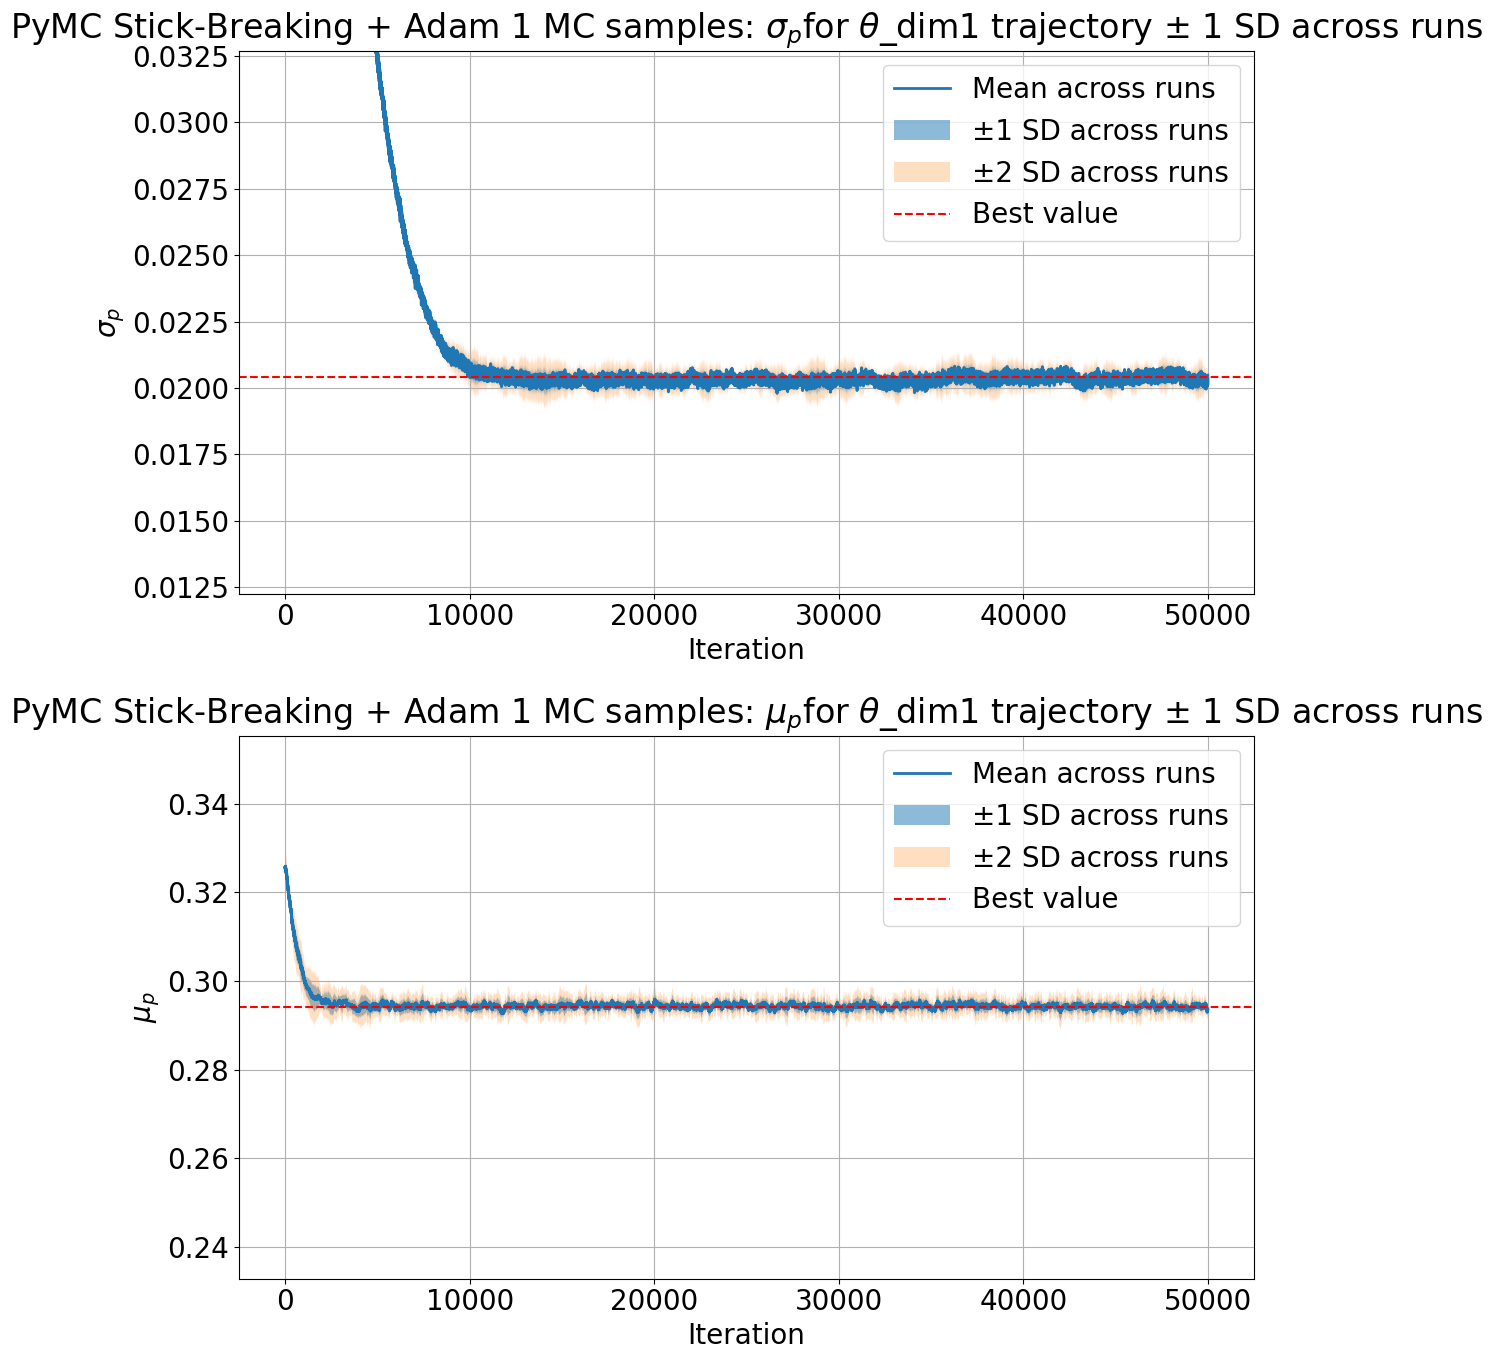

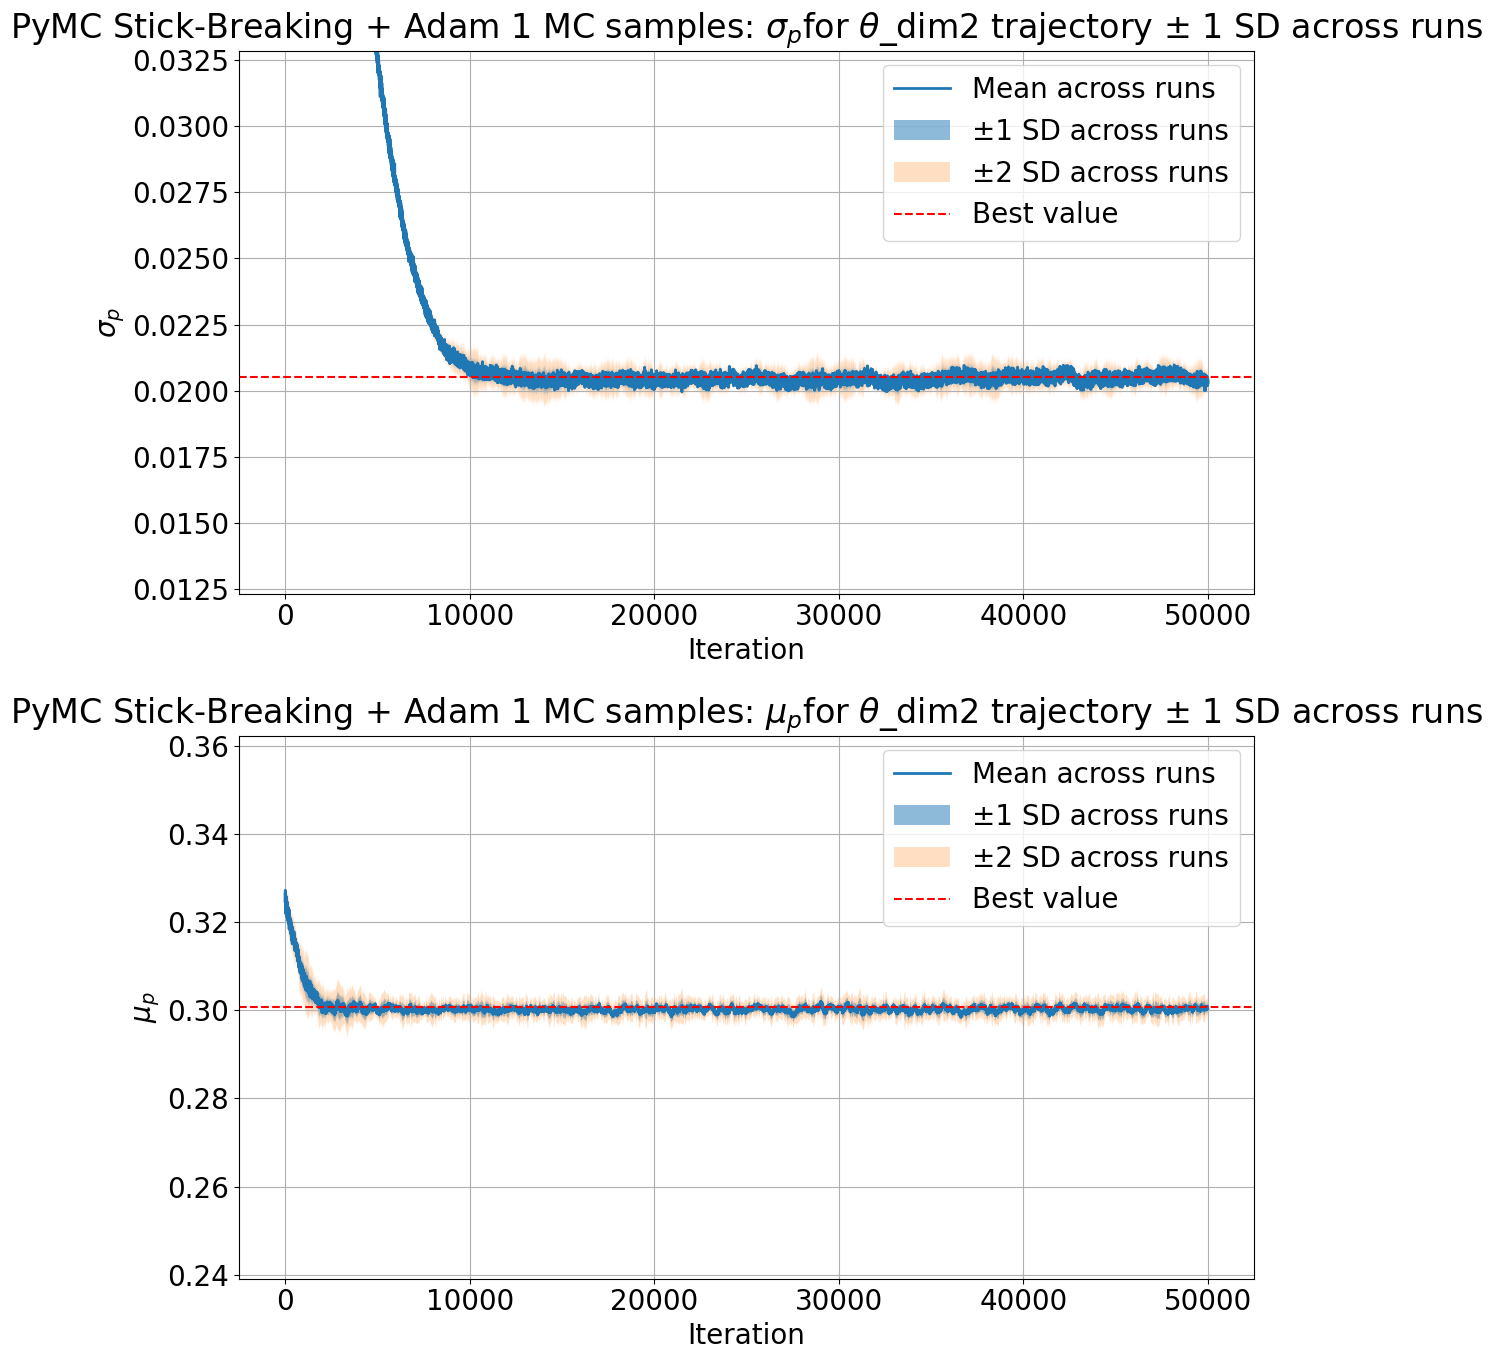

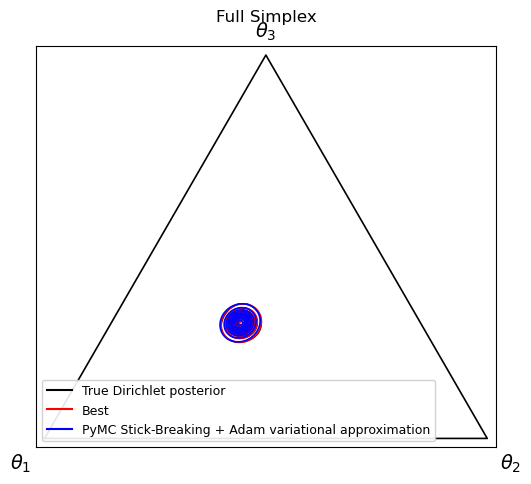

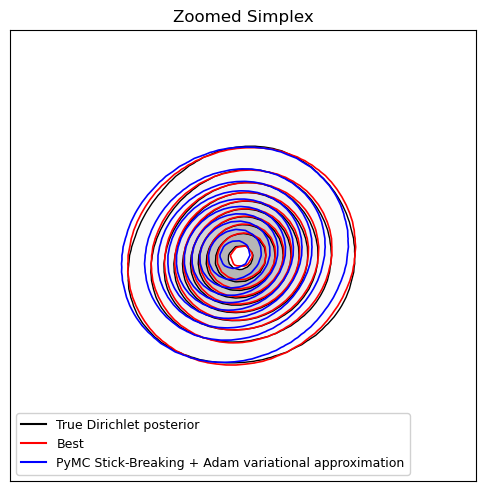

18.33723
18.334362
18.32882
18.310492
18.348278
18.32597
18.351772
18.34155
18.36848
18.32137


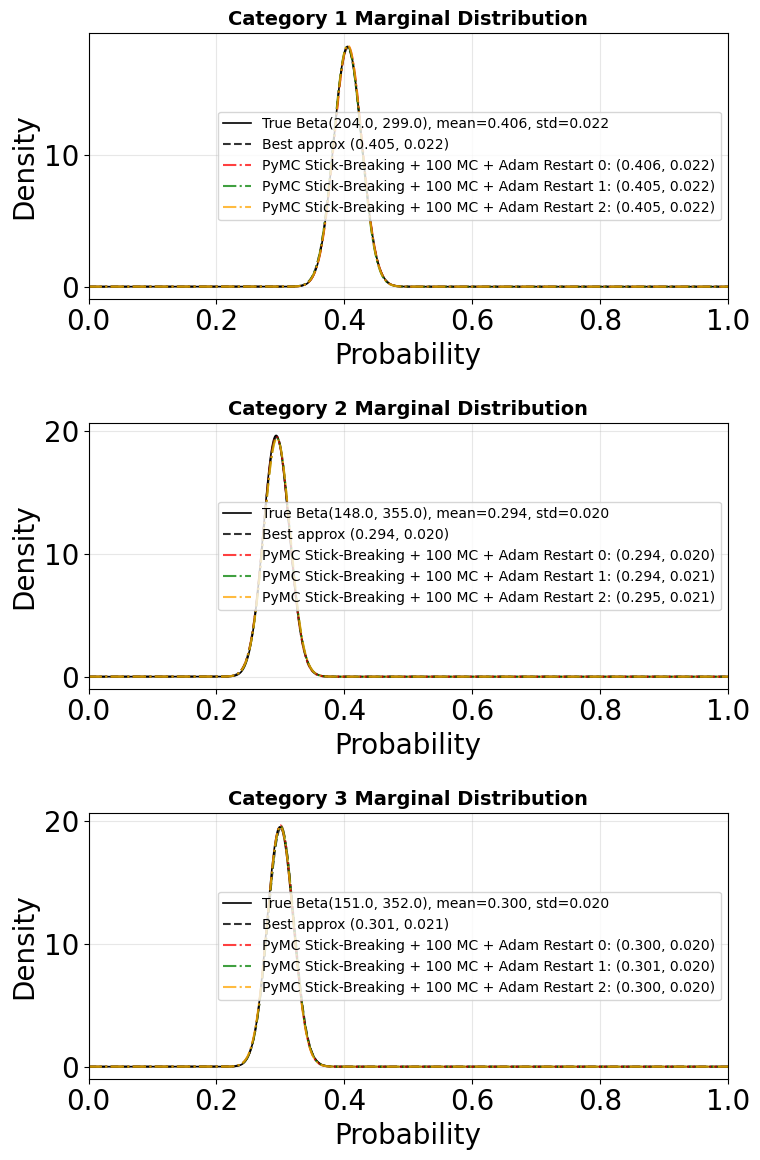

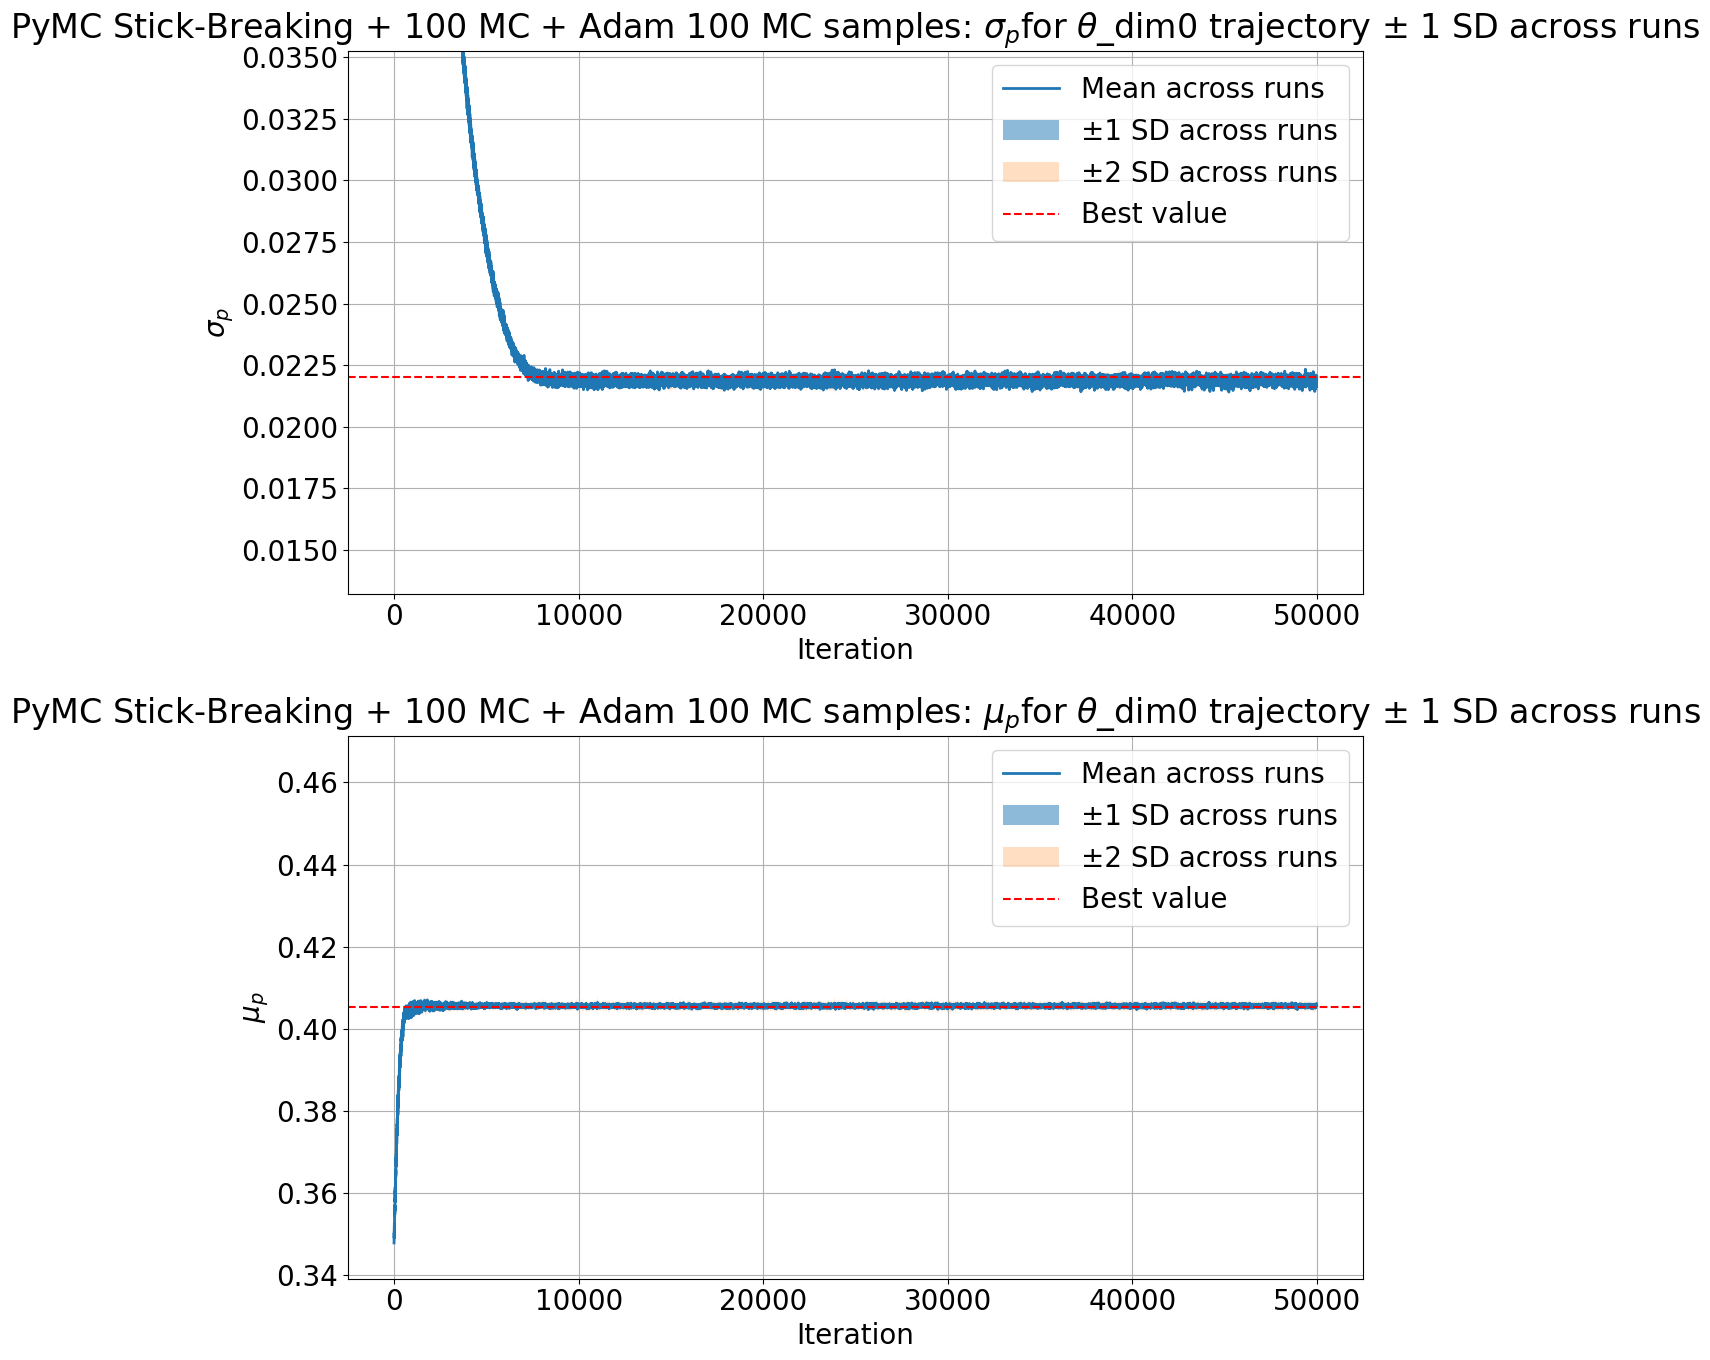

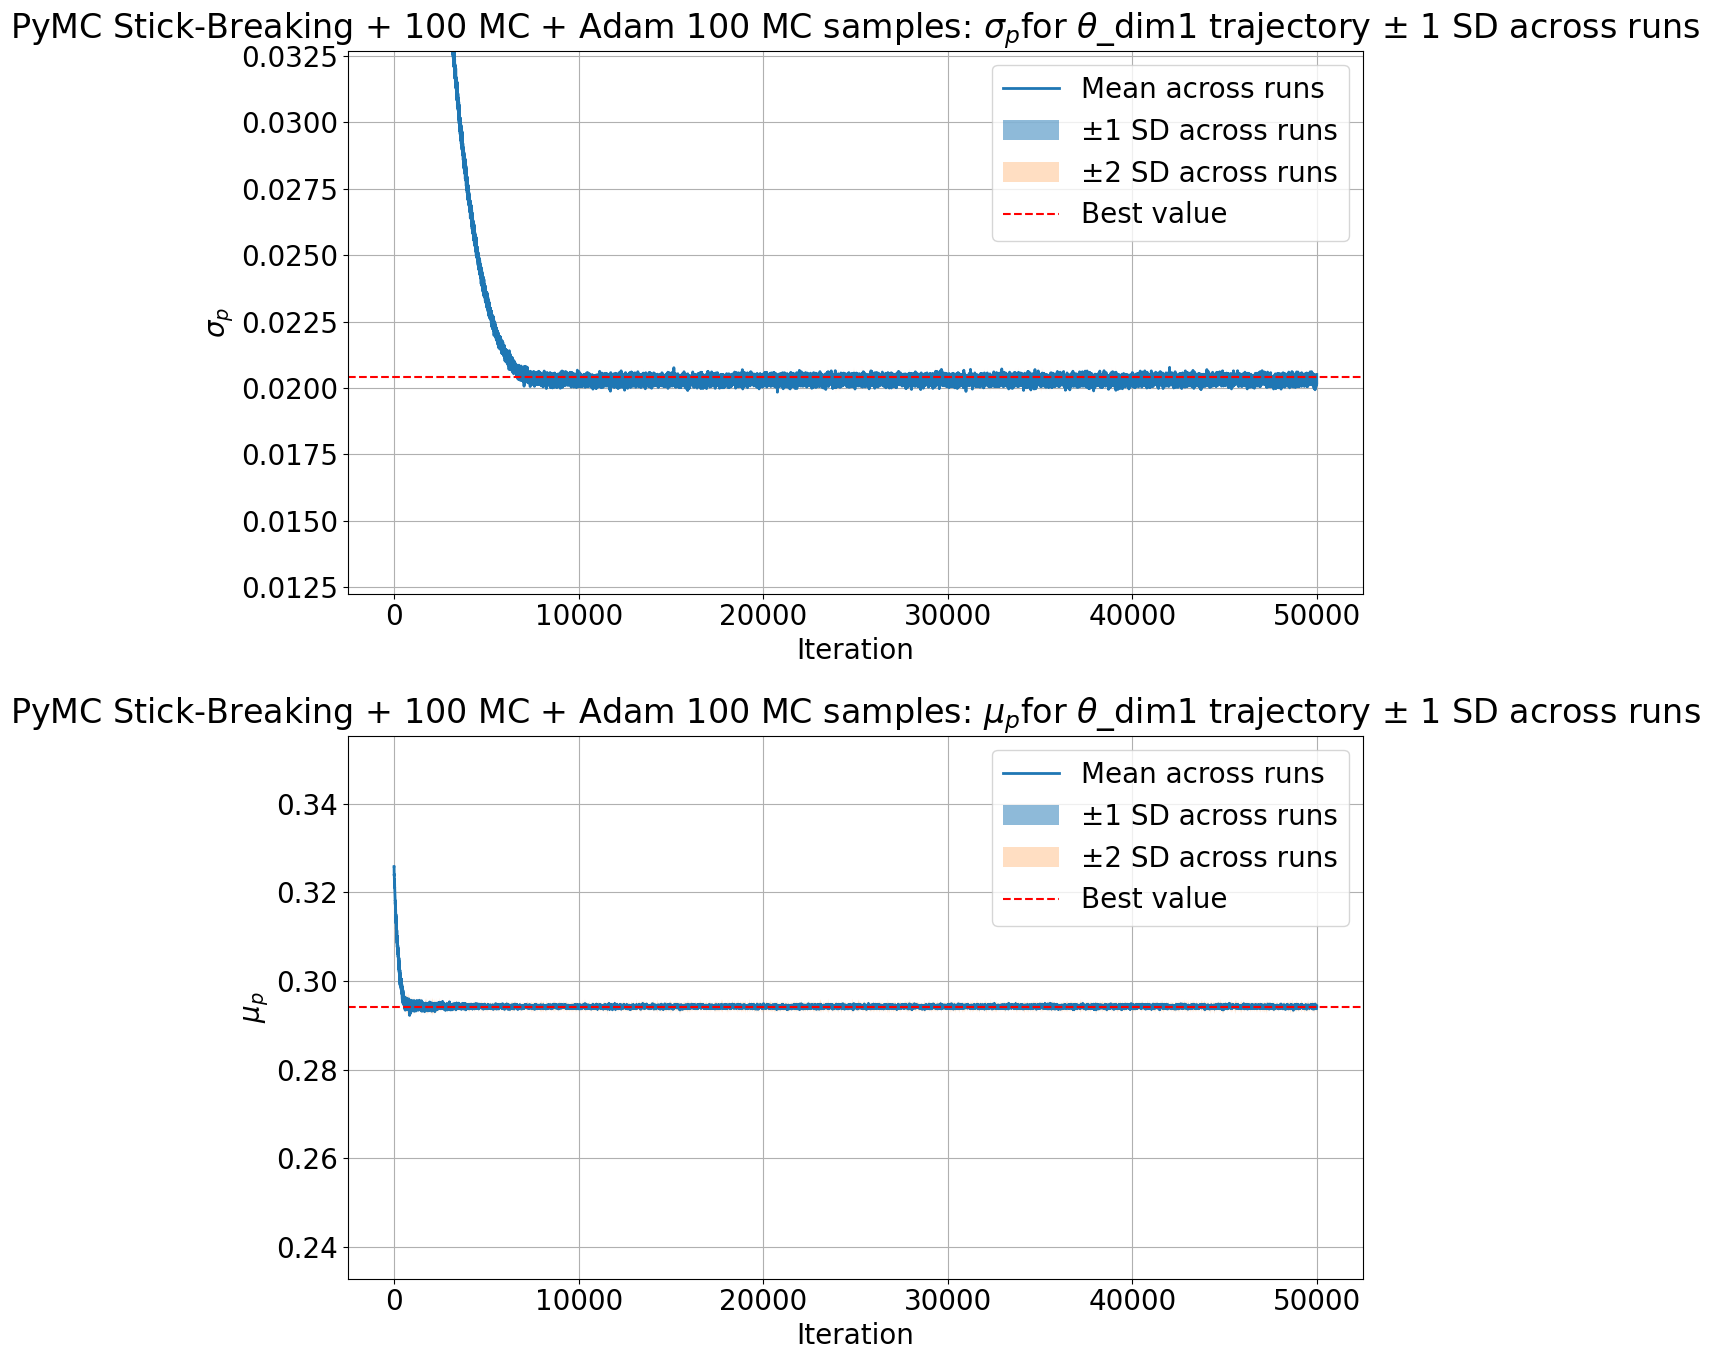

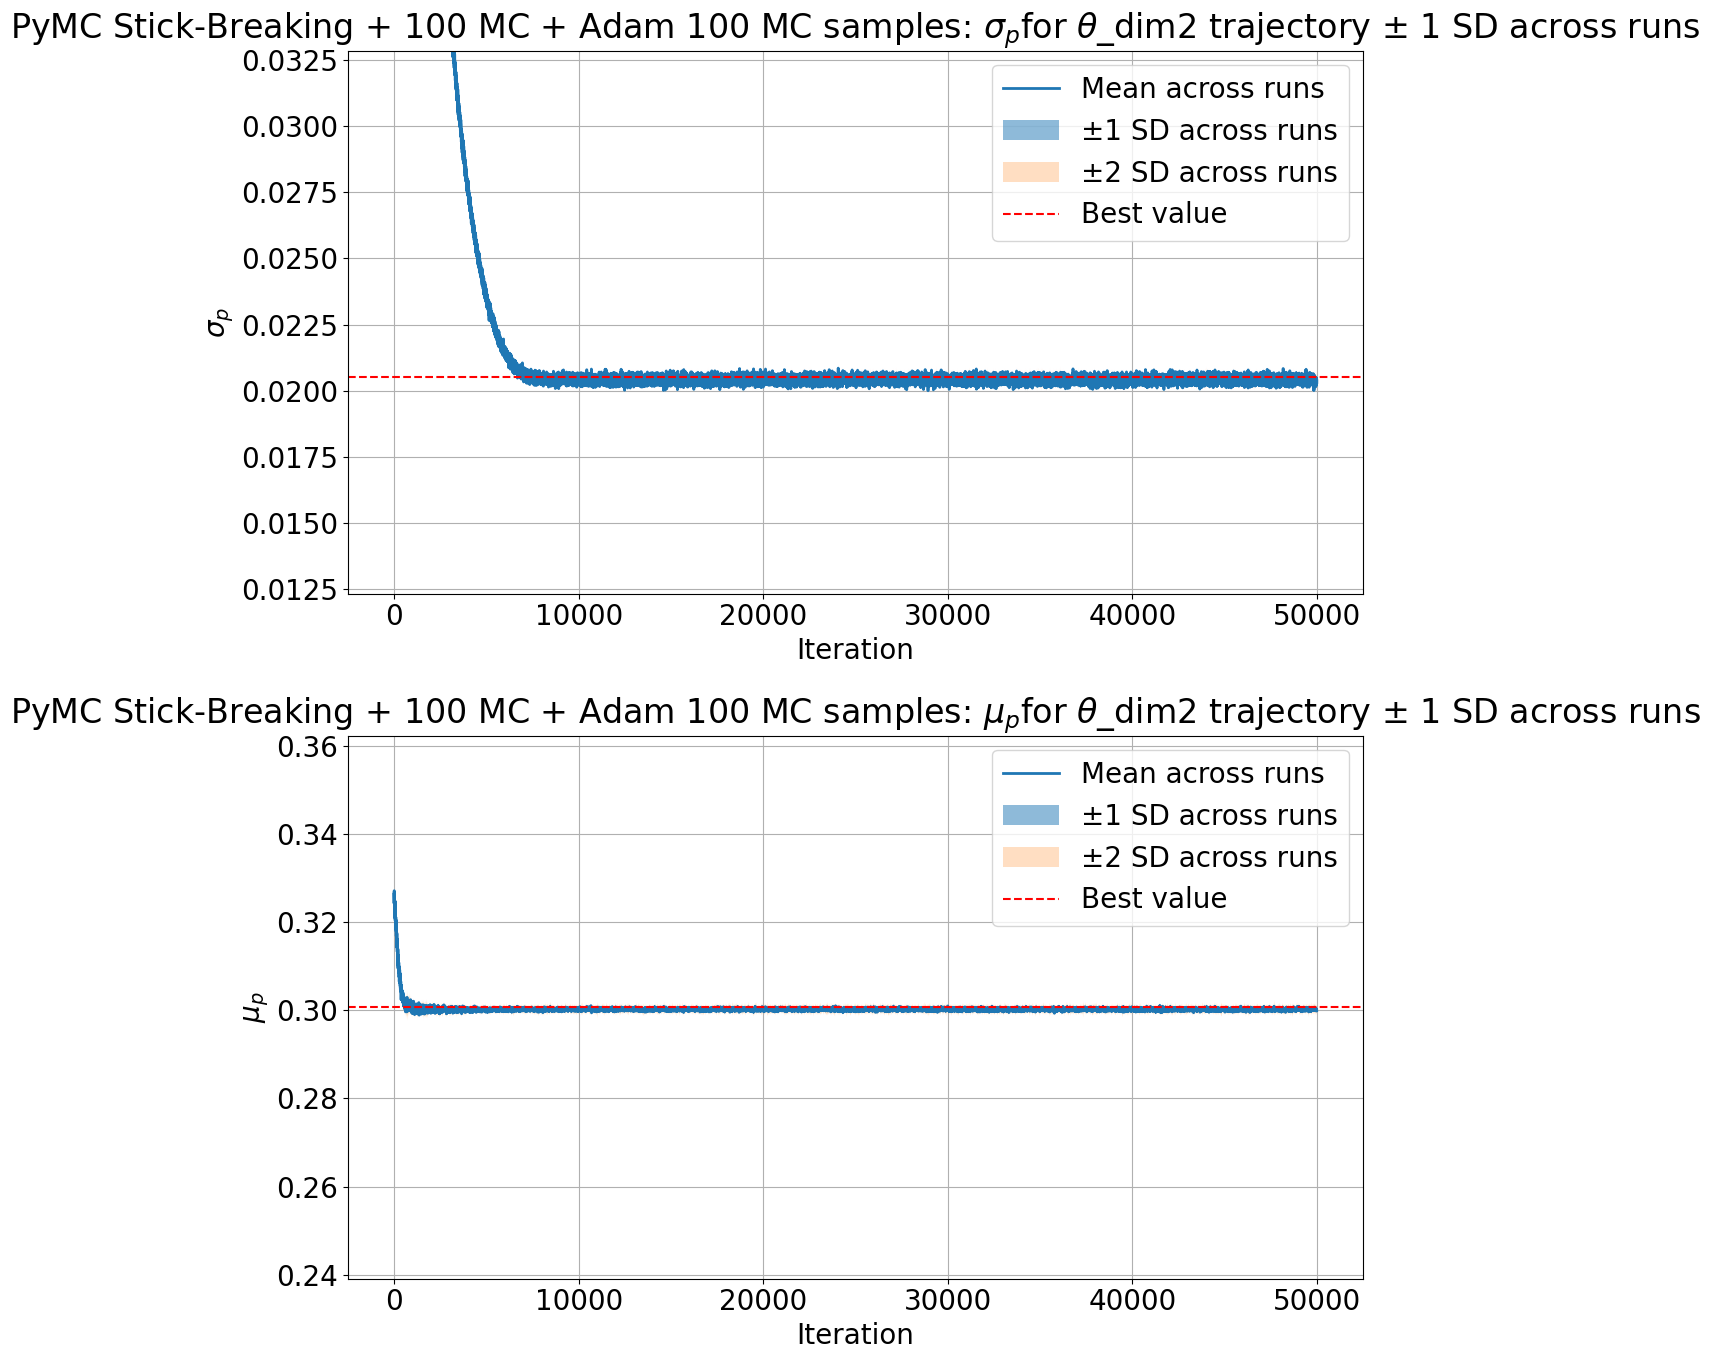

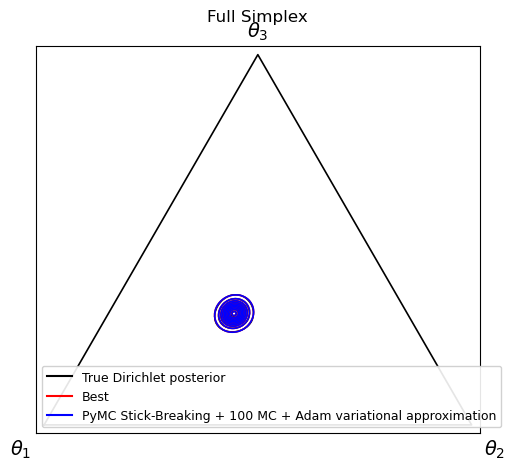

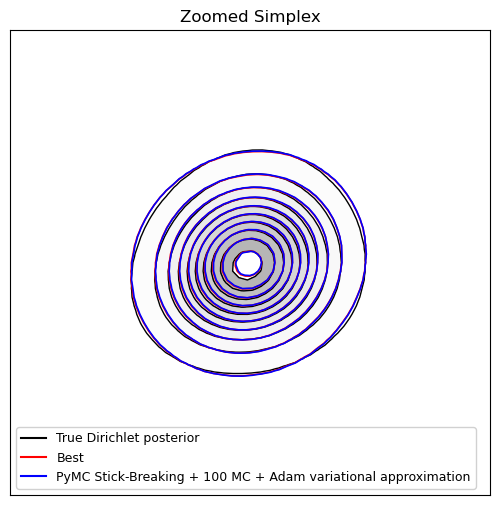

In [8]:
for scenario_name, meta in scenario_meta.items():
    plot_pymc_scenario(
        loaded_processed_scenarios[scenario_name],
        loaded_summary_files[scenario_name],
        meta["title"],
        n_mc_samps=meta["n_mc_samps"],
    )
